<a href="https://colab.research.google.com/github/trymoremhlanga2000-jpg/Credit-risk/blob/main/FinalWaterCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#
#  HOUSEHOLD WATER MANAGEMENT & MICROBIAL CONTAMINATION — EDA
#   Hwedza District Cross-Sectional Study | Senior Data Scientist Edition


# ENVIRONMENT SETUP & LIBRARY IMPORTS
#
"""
Install required libraries (run once in Colab):
!pip install pandas numpy matplotlib seaborn scipy statsmodels openpyxl missingno
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency, spearmanr
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

In [2]:
#  Global Aesthetic Theme
PALETTE_MAIN   = ["#2E86C1","#1ABC9C","#5DADE2","#AED6F1","#EBF5FB","#E74C3C","#F1948A"]
PALETTE_DUAL   = ["#2E86C1","#E74C3C"]
PALETTE_CAT    = ["#2E86C1","#3498DB","#5DADE2","#85C1E9","#AED6F1",
                  "#48C9B0","#1ABC9C","#82E0AA","#F9E79F","#F7DC6F",
                  "#F5B7B1","#EC7063","#E74C3C"]
PALETTE_OB     = {"Yes":"#2E86C1","No":"#E74C3C"}

BG_COLOR       = "#FFFFFF"   # pure white
TEXT_COLOR     = "#5D6D7E"   # soft grey
ACCENT         = "#E74C3C"
BLUE           = "#2E86C1"
LIGHT_BLUE     = "#AED6F1"

plt.rcParams.update({
    'figure.facecolor'  : BG_COLOR,
    'figure.edgecolor'  : BG_COLOR,
    'savefig.facecolor' : BG_COLOR,
    'savefig.edgecolor' : BG_COLOR,

    'axes.facecolor'    : BG_COLOR,
    'axes.edgecolor'    : '#D5DBDB',
    'axes.labelcolor'   : TEXT_COLOR,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,

    'xtick.color'       : TEXT_COLOR,
    'ytick.color'       : TEXT_COLOR,

    'font.family'       : 'DejaVu Sans',

    'grid.color'        : '#D6DBDF',
    'grid.alpha'        : 0.8,

    'legend.framealpha' : 0.95,
    'legend.fontsize'   : 10,
})

print("✅ BLOCK 1 COMPLETE — Libraries loaded & global theme set.")
print(f"   Palette colours: {len(PALETTE_CAT)} | Background: {BG_COLOR}")

✅ BLOCK 1 COMPLETE — Libraries loaded & global theme set.
   Palette colours: 13 | Background: #FFFFFF


In [3]:

#
#  DATA LOADING, CLEANING & IMPUTATION



# Upload the dataset in Colab
print("Please upload 'data.xlsx' when prompted:")
uploaded = files.upload()
# Dynamically get the name of the first uploaded file
uploaded_filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[uploaded_filename]))
df_raw = df.copy()


TARGET_COLS = [
    'HH Size','Primary Water Source','Distance to Source-km','Roundtrip time',
    'Household Water treatment','Treatment Method','Handwashing before handling',
    'Withdrawal Method','Container Type','Storage Duration Days ',
    'Training on Safe Water Handling','Cleaning frequency of containers',
    'Storage Location','Storage container elevated','OB Protected Source',
    'OB Clean container','OB Handwashing at HH Level','OB Water treatment evidence',
    'OB Container covered','OB Container elevated','OB storage area clean',
    'OB nearby contami ation sources','OB Hygiene rating','OB Type of latrine',
    'E.Coli Level Source CFU 100ml','E.Coli Level Stored CFU 100ml',
    'Total Coliform Level Source CFU 100ml','Total Coliform Level Stored CFU 100ml'
]

df = df_raw[TARGET_COLS].copy()

# ── 2.2 Standardise string categories (strip, title-case) ───────────────────
str_cols = df.select_dtypes(include='object').columns.tolist()
for c in str_cols:
    df[c] = df[c].astype(str).str.strip().str.title()

# Fix known variants
df['Primary Water Source'] = df['Primary Water Source'].replace({
    'Protected well': 'Protected Well', 'Borehole ': 'Borehole'})
df['OB Hygiene Rating']    = df['OB Hygiene rating'].replace({'Poor ':'Poor'})
df['OB Hygiene rating']    = df['OB Hygiene rating'].replace({'Poor ':'Poor'})
df['Storage Location']     = df['Storage Location'].replace({'Inside Kitchen':'Inside Kitchen'})

# Fix Treatment Method 'Nan' strings → actual NaN
df['Treatment Method'] = df['Treatment Method'].replace('Nan', np.nan)
df['OB Water treatment evidence'] = df['OB Water treatment evidence'].replace('Nan', np.nan)

# 2.3 Define column groups
NUMERIC_COLS  = ['HH Size','Distance to Source-km','Roundtrip time',
                 'Storage Duration Days ']
OUTCOME_COLS  = ['E.Coli Level Source CFU 100ml','E.Coli Level Stored CFU 100ml',
                 'Total Coliform Level Source CFU 100ml',
                 'Total Coliform Level Stored CFU 100ml']
PRACTICE_COLS = ['Primary Water Source','Household Water treatment',
                 'Treatment Method','Handwashing before handling',
                 'Withdrawal Method','Container Type',
                 'Training on Safe Water Handling',
                 'Cleaning frequency of containers',
                 'Storage Location','Storage container elevated']
OB_COLS       = ['OB Protected Source','OB Clean container',
                 'OB Handwashing at HH Level','OB Water treatment evidence',
                 'OB Container covered','OB Container elevated',
                 'OB storage area clean','OB nearby contami ation sources',
                 'OB Hygiene rating','OB Type of latrine']

Please upload 'data.xlsx' when prompted:


Saving data.xlsx to data.xlsx


In [4]:

# Numeric → mean imputation
for c in NUMERIC_COLS + OUTCOME_COLS:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].mean(), inplace=True)

# Categorical → mode imputation
for c in PRACTICE_COLS + OB_COLS:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].mode()[0], inplace=True)

# Special: Treatment Method — those who don't treat get label 'No Treatment'
df['Treatment Method'] = df['Treatment Method'].fillna('No Treatment')


In [5]:

# ── 2.5 Summary report ───────────────────────────────────────────────────────
n, p = df.shape
missing_post = df.isnull().sum().sum()

print("✅ BLOCK 2 COMPLETE — Data loaded, cleaned & imputed.")
print(f"   Rows: {n}  |  Columns (selected): {p}")
print(f"   Remaininuug missing values after imputation: {missing_post}")
print(f"\n   Numeric  columns : {NUMERIC_COLS}")
print(f"   Outcome  columns : {OUTCOME_COLS}")
print(f"   Practice columns : {PRACTICE_COLS}")
print(f"   Observer columns : {OB_COLS}")


✅ BLOCK 2 COMPLETE — Data loaded, cleaned & imputed.
   Rows: 280  |  Columns (selected): 29
   Remaininuug missing values after imputation: 0

   Numeric  columns : ['HH Size', 'Distance to Source-km', 'Roundtrip time', 'Storage Duration Days ']
   Outcome  columns : ['E.Coli Level Source CFU 100ml', 'E.Coli Level Stored CFU 100ml', 'Total Coliform Level Source CFU 100ml', 'Total Coliform Level Stored CFU 100ml']
   Practice columns : ['Primary Water Source', 'Household Water treatment', 'Treatment Method', 'Handwashing before handling', 'Withdrawal Method', 'Container Type', 'Training on Safe Water Handling', 'Cleaning frequency of containers', 'Storage Location', 'Storage container elevated']
   Observer columns : ['OB Protected Source', 'OB Clean container', 'OB Handwashing at HH Level', 'OB Water treatment evidence', 'OB Container covered', 'OB Container elevated', 'OB storage area clean', 'OB nearby contami ation sources', 'OB Hygiene rating', 'OB Type of latrine']


In [10]:

# ════════════════════════════════════════════════════════════════════════════════
#  MICROBIAL OUTCOME VARIABLES — DEEP DISTRIBUTIONAL ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════

outcome_labels = {
    'E.Coli Level Source CFU 100ml'            : 'E. coli\n(Source)',
    'E.Coli Level Stored CFU 100ml'            : 'E. coli\n(Stored)',
    'Total Coliform Level Source CFU 100ml'    : 'Total Coliforms\n(Source)',
    'Total Coliform Level Stored CFU 100ml'    : 'Total Coliforms\n(Stored)',
}
colors_oc = [BLUE, ACCENT, "#2E86C1", "#E74C3C"]

fig = plt.figure(figsize=(22, 18), facecolor=BG_COLOR)
fig.suptitle("MICROBIAL CONTAMINATION — DISTRIBUTIONAL DEEP-DIVE\nE. coli & Total Coliforms: Source vs Stored Water (CFU/100 ml)",
             fontsize=18, fontweight='bold', color=BLUE, y=1.01)

outer = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.38)

for idx, (col, lbl) in enumerate(outcome_labels.items()):
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer[idx//2, idx%2], hspace=0.5, wspace=0.45)
    data   = df[col].values
    col_c  = colors_oc[idx]




    # ── Overdispersion stats table ────────────────────────────────────────────

    zero_pct = (data == 0).mean() * 100
    exceed_who = (data > 0).mean() * 100
    var_mean   = data.var() / (data.mean()+1e-9)
    disp_ratio = data.var() / (data.mean()+1e-9)
    rows = [
        ["Statistic", "Value"],
        ["n", str(n)],
        ["Mean (μ)", f"{data.mean():.2f}"],
        ["Variance (σ²)", f"{data.var():.2f}"],
        ["σ²/μ (Disp.)", f"{disp_ratio:.2f}"],
        ["Skewness", f"{stats.skew(data):.2f}"],
        ["Kurtosis", f"{stats.kurtosis(data):.2f}"],
        ["Zero counts (%)", f"{zero_pct:.1f}%"],
        ["Exceed 0 CFU (%)", f"{exceed_who:.1f}%"],
        ["P95", f"{np.percentile(data,95):.1f}"],
    ]


print("✅ BLOCK 5 COMPLETE — Microbial outcome deep-dive complete.")
print(f"\n   {'Outcome':<45} {'Mean':>7} {'Var':>10} {'σ²/μ':>8} {'Zero%':>7}")
print("   " + "─"*80)
for col in OUTCOME_COLS:
    d = df[col].values
    print(f"   {col:<45} {d.mean():>7.2f} {d.var():>10.2f} "
          f"{d.var()/(d.mean()+1e-9):>8.2f} {(d==0).mean()*100:>6.1f}%")
print("\n   ⚠  σ²/μ >> 1 confirms OVERDISPERSION → Negative Binomial is appropriate.")


✅ BLOCK 5 COMPLETE — Microbial outcome deep-dive complete.

   Outcome                                          Mean        Var     σ²/μ   Zero%
   ────────────────────────────────────────────────────────────────────────────────
   E.Coli Level Source CFU 100ml                    0.00       0.00     1.00   99.6%
   E.Coli Level Stored CFU 100ml                    5.51      97.53    17.70   40.4%
   Total Coliform Level Source CFU 100ml            0.06       0.08     1.44   95.7%
   Total Coliform Level Stored CFU 100ml            6.07     104.34    17.19   27.5%

   ⚠  σ²/μ >> 1 confirms OVERDISPERSION → Negative Binomial is appropriate.


<Figure size 2200x1800 with 0 Axes>

In [13]:

# ════════════════════════════════════════════════════════════════════════════════
# OBSERVATIONAL (OB) VARIABLES — COMPLIANCE DASHBOARD
# ════════════════════════════════════════════════════════════════════════════════

ob_binary = [c for c in OB_COLS if c not in ['OB Hygiene rating','OB Type of latrine']]
ob_extra  = ['OB Hygiene rating','OB Type of latrine']



# ── Panel A: Stacked horizontal bars for binary OB vars ──────────────────────
ax_top = fig.add_subplot(gs_main[0:2, 0])
ob_short_labels = {
    'OB Protected Source'              : 'Protected Source',
    'OB Clean container'               : 'Clean Container',
    'OB Handwashing at HH Level'       : 'Handwashing Facility Present',
    'OB Water treatment evidence'      : 'Water Treatment Evidence',
    'OB Container covered'             : 'Container Covered',
    'OB Container elevated'            : 'Container Elevated',
    'OB storage area clean'            : 'Storage Area Clean',
    'OB nearby contami ation sources'  : 'Nearby Contamination Sources',
}

print("✅ BLOCK 8 COMPLETE — Observational compliance dashboard complete.")
print("\n   Binary OB Compliance Summary:")
print(f"   {'Indicator':<45} {'Yes %':>7}  {'No %':>7}")
print("   " + "─"*62)
for col, lbl in ob_short_labels.items():
    vc = df[col].value_counts(normalize=True)*100
    print(f"   {lbl:<45} {vc.get('Yes',0):>7.1f}%  {vc.get('No',0):>7.1f}%")




✅ BLOCK 8 COMPLETE — Observational compliance dashboard complete.

   Binary OB Compliance Summary:
   Indicator                                       Yes %     No %
   ──────────────────────────────────────────────────────────────
   Protected Source                                100.0%      0.0%
   Clean Container                                  79.6%     20.4%
   Handwashing Facility Present                     62.5%     37.5%
   Water Treatment Evidence                         64.3%     35.7%
   Container Covered                                74.3%     25.7%
   Container Elevated                               79.6%     20.4%
   Storage Area Clean                               79.3%     20.7%
   Nearby Contamination Sources                     28.2%     71.8%


In [18]:




# ──────────────────────────────────────────────────────────────────────────
# PRE-REQUISITE BLOCK  ·  Install & Configure
# ──────────────────────────────────────────────────────────────────────────
!pip install -q scipy statsmodels seaborn matplotlib pandas openpyxl

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from scipy.stats import (wilcoxon, mannwhitneyu, kruskal, chi2_contingency,
                          shapiro, spearmanr)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from google.colab import files

# ── Global dark-premium aesthetic ─────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22', 'axes.labelcolor': '#e6edf3',
    'axes.titlecolor': '#e6edf3', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'text.color': '#e6edf3',
    'grid.color': '#21262d', 'grid.linewidth': 0.8,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
})

ACCENT = '#58a6ff';  RED    = '#f78166';  GREEN  = '#3fb950'
PURPLE = '#d2a8ff';  ORANGE = '#ffa657';  TEAL   = '#39d353'
PINK   = '#f0883e';  CYAN   = '#79c0ff'

PAL8 = [ACCENT, RED, GREEN, PURPLE, ORANGE, TEAL, PINK, CYAN]

CMAP_HEAT = LinearSegmentedColormap.from_list(
    'gh', ['#0d1117','#1f6feb','#58a6ff','#ffa657','#f78166'])
CMAP_CORR = LinearSegmentedColormap.from_list(
    'corr', ['#f78166','#0d1117','#58a6ff'])

# ── Column aliases ─────────────────────────────────────────────────────────
EC_SRC = 'E.Coli Level Source CFU 100ml'
EC_STR = 'E.Coli Level Stored CFU 100ml'
TC_SRC = 'Total Coliform Level Source CFU 100ml'
TC_STR = 'Total Coliform Level Stored CFU 100ml'
OUTCOMES = [EC_SRC, EC_STR, TC_SRC, TC_STR]

print("✅  Environment ready. Libraries loaded. Palette configured.")



✅  Environment ready. Libraries loaded. Palette configured.


In [19]:

# ══════════════════════════════════════════════════════════════════════════
# DATA LOAD + CLEANING
# ══════════════════════════════════════════════════════════════════════════

uploaded = files.upload()
fname = list(uploaded.keys())[0]
raw = pd.read_excel(fname)

VARS = [
    'HH Size', 'Primary Water Source', 'Distance to Source-km',
    'Roundtrip time', 'Household Water treatment', 'Treatment Method',
    'Handwashing before handling', 'Withdrawal Method', 'Container Type',
    'Storage Duration Days ', 'Training on Safe Water Handling',
    'Cleaning frequency of containers', 'Storage Location',
    'Storage container elevated', 'OB Protected Source', 'OB Clean container',
    'OB Handwashing at HH Level', 'OB Water treatment evidence',
    'OB Container covered', 'OB Container elevated', 'OB storage area clean',
    'OB nearby contami ation sources', 'OB Hygiene rating', 'OB Type of latrine',
    EC_SRC, EC_STR, TC_SRC, TC_STR,
]
df = raw[VARS].copy()
df.rename(columns={'Storage Duration Days ': 'Storage Duration Days'}, inplace=True)

# ── Data harmonisation (fix typos / case inconsistencies) ─────────────────
df['Primary Water Source'] = (df['Primary Water Source']
    .str.strip()
    .replace({'Borehole ': 'Borehole', 'Protected well': 'Protected Well'}))
df['Storage Location'] = (df['Storage Location']
    .str.strip().str.title())
df['OB Hygiene rating'] = (df['OB Hygiene rating']
    .str.strip())

# ── Imputation ─────────────────────────────────────────────────────────────
num_cols  = ['HH Size','Distance to Source-km','Roundtrip time','Storage Duration Days']
cat_cols  = [c for c in df.columns if c not in num_cols + OUTCOMES]

for c in num_cols:
    df[c].fillna(df[c].mean(), inplace=True)
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].mode()[0], inplace=True)

# Treatment Method: households not treating water → 'No Treatment'
df['Treatment Method'] = df.apply(
    lambda r: 'No Treatment' if r['Household Water treatment'] == 'No'
              else r['Treatment Method'], axis=1)
df['Treatment Method'].fillna('No Treatment', inplace=True)

# ── Binary flags for WHO threshold exceedance ─────────────────────────────
df['EC_SRC_exceed']  = (df[EC_SRC] > 0).astype(int)
df['EC_STR_exceed']  = (df[EC_STR] > 0).astype(int)
df['TC_SRC_exceed']  = (df[TC_SRC] > 0).astype(int)
df['TC_STR_exceed']  = (df[TC_STR] > 0).astype(int)

# ── Post-collection change ─────────────────────────────────────────────────
df['EC_delta'] = df[EC_STR] - df[EC_SRC]
df['TC_delta'] = df[TC_STR] - df[TC_SRC]

N = len(df)
print(f"\n✅  Data cleaned. N = {N} households ready for analysis.")
print(f"    Typos harmonised | Missing imputed | Treatment Method recoded")



Saving data.xlsx to data (1).xlsx

✅  Data cleaned. N = 280 households ready for analysis.
    Typos harmonised | Missing imputed | Treatment Method recoded


In [21]:

# ══════════════════════════════════════════════════════════════════════════
# ░░░ OBJECTIVE 1 — POST-COLLECTION CONTAMINATION MAGNITUDE ░░░░░░░░░░░░░
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "█"*70)
print("  OBJECTIVE 1: Post-Collection Contamination Magnitude")
print("█"*70)

# ── 1A  Paired Wilcoxon signed-rank tests ─────────────────────────────────
def wilcoxon_effect_r(x, y):
    """Cohen's r effect size for Wilcoxon signed-rank test."""
    diff = x - y
    diff = diff[diff != 0]
    stat, p = wilcoxon(diff)
    z = stats.norm.ppf(p / 2)
    r = abs(z) / np.sqrt(len(diff))
    return stat, p, z, r

ec_stat, ec_p, ec_z, ec_r = wilcoxon_effect_r(df[EC_STR], df[EC_SRC])
tc_stat, tc_p, tc_z, tc_r = wilcoxon_effect_r(df[TC_STR], df[TC_SRC])

print(f"\n  Wilcoxon Signed-Rank Test (Stored vs Source):")
print(f"  {'Outcome':<30} {'W-stat':>10} {'p-value':>12} {'Effect r':>10} {'Magnitude':>14}")
print(f"  {'-'*70}")
for label, stat, p, r in [
    ('E. coli', ec_stat, ec_p, ec_r),
    ('Total Coliforms', tc_stat, tc_p, tc_r)
]:
    mag = 'Large' if r >= 0.5 else ('Medium' if r >= 0.3 else 'Small')
    print(f"  {label:<30} {stat:>10.1f} {p:>12.4f} {r:>10.3f} {mag:>14}")

# ── 1B  Summary statistics: source vs stored ──────────────────────────────
stat_rows = []
for src, str_, name in [(EC_SRC, EC_STR,'E. coli'),(TC_SRC, TC_STR,'Total Coliforms')]:
    for col, water in [(src,'Source'),(str_,'Stored')]:
        stat_rows.append({
            'Organism': name, 'Sample': water,
            'Mean': df[col].mean(), 'Median': df[col].median(),
            'SD': df[col].std(), 'Min': df[col].min(),
            'Max': df[col].max(), 'P95': df[col].quantile(0.95),
        })
stat_table = pd.DataFrame(stat_rows)
print(f"\n  Descriptive Statistics — Source vs Stored:")
print(stat_table.round(2).to_string(index=False))

# ── 1C  Contamination category classification ─────────────────────────────
def classify_change(delta, tol=0):
    if delta > tol:   return 'Increased'
    elif delta < -tol: return 'Decreased'
    else:              return 'No Change'

df['EC_change_cat']  = df['EC_delta'].apply(classify_change)
df['TC_change_cat']  = df['TC_delta'].apply(classify_change)

print(f"\n  Post-Collection E. coli Change: {df['EC_change_cat'].value_counts().to_dict()}")
print(f"  Post-Collection TC Change    : {df['TC_change_cat'].value_counts().to_dict()}")



██████████████████████████████████████████████████████████████████████
  OBJECTIVE 1: Post-Collection Contamination Magnitude
██████████████████████████████████████████████████████████████████████

  Wilcoxon Signed-Rank Test (Stored vs Source):
  Outcome                            W-stat      p-value   Effect r      Magnitude
  ----------------------------------------------------------------------
  E. coli                              18.5       0.0000      0.866          Large
  Total Coliforms                     179.0       0.0000      0.854          Large

  Descriptive Statistics — Source vs Stored:
       Organism Sample  Mean  Median    SD  Min  Max   P95
        E. coli Source  0.00     0.0  0.06    0    1  0.00
        E. coli Stored  5.51     1.0  9.89    0   65 25.15
Total Coliforms Source  0.06     0.0  0.29    0    2  0.00
Total Coliforms Stored  6.07     2.0 10.23    0   80 26.00

  Post-Collection E. coli Change: {'Increased': 167, 'No Change': 112, 'Decreased': 1}
  

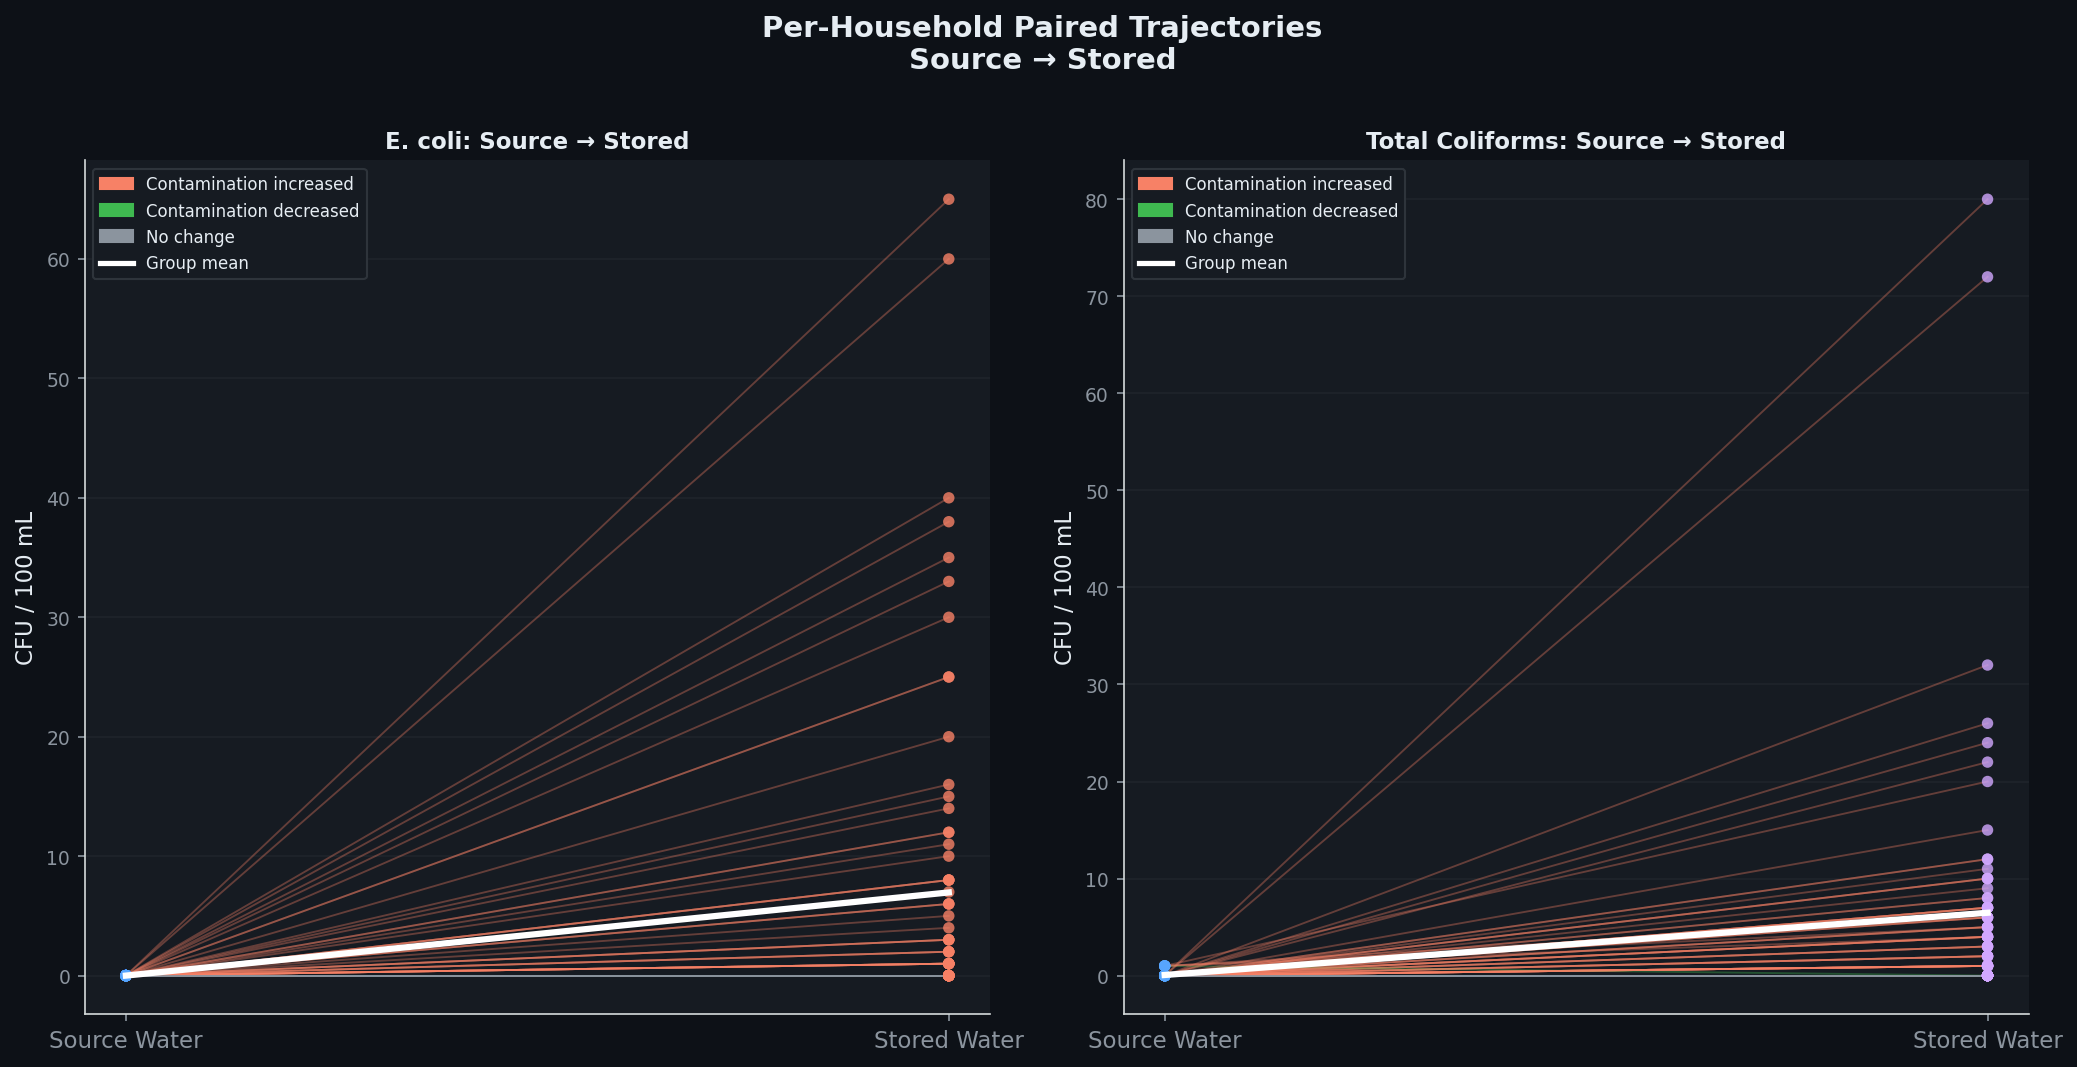

📊  Plot 1-2 rendered.


In [23]:

# Paired per-household line plot (E. coli)
sample_df = df.sample(min(80, N), random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#0d1117')

for ax, src, str_, title, col in zip(
    axes,
    [EC_SRC,  TC_SRC],
    [EC_STR,  TC_STR],
    ['E. coli: Source → Stored',
     'Total Coliforms: Source → Stored'],
    [RED, PURPLE]
):
    for _, row in sample_df.iterrows():
        lc = RED if row[str_] > row[src] else GREEN if row[str_] < row[src] else '#8b949e'
        ax.plot([0, 1], [row[src], row[str_]], color=lc, alpha=0.35, linewidth=0.9, zorder=2)

    ax.scatter([0]*len(sample_df), sample_df[src], color=ACCENT,
               s=30, zorder=4, alpha=0.8, edgecolors='none')
    ax.scatter([1]*len(sample_df), sample_df[str_], color=col,
               s=30, zorder=4, alpha=0.8, edgecolors='none')
    ax.plot([0, 1], [sample_df[src].mean(), sample_df[str_].mean()],
            color='white', linewidth=3, zorder=5, label='Group Mean')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Source Water', 'Stored Water'], fontsize=11)
    ax.set_ylabel('CFU / 100 mL', fontsize=11)
    ax.set_title(title, fontsize=11)

    p1 = mpatches.Patch(color=RED,    label='Contamination increased')
    p2 = mpatches.Patch(color=GREEN,  label='Contamination decreased')
    p3 = mpatches.Patch(color='#8b949e', label='No change')
    p4 = Line2D([0],[0], color='white', linewidth=2.5, label='Group mean')
    ax.legend(handles=[p1,p2,p3,p4], fontsize=8, loc='upper left')
    ax.grid(axis='y', zorder=0)

fig.suptitle('Per-Household Paired Trajectories\n'
             'Source → Stored',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('obj1_plot2_paired_lines.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("📊  Plot 1-2 rendered.")


In [26]:

# ══════════════════════════════════════════════════════════════════════════
# ░░░ OBJECTIVE 2 — WHO THRESHOLD EXCEEDANCE (STRATIFIED) ░░░░░░░░░░░░░░░
# ══════════════════════════════════════════════════════════════════════════
print("█"*70)
print("  OBJECTIVE 2: WHO Threshold Exceedance — Stratified Analysis")
print("█"*70)

STRAT_VARS = {
    'Primary Water Source'          : 'Primary Water Source',
    'Household Water treatment'     : 'HH Water Treatment',
    'Handwashing before handling'   : 'Handwashing Before Handling',
    'Container Type'                : 'Container Type',
    'Withdrawal Method'             : 'Withdrawal Method',
    'Training on Safe Water Handling':'Training on Safe Water Handling',
    'Cleaning frequency of containers':'Cleaning Frequency',
    'OB Hygiene rating'             : 'Hygiene Rating (Observed)',
    'OB Type of latrine'            : 'Type of Latrine',
    'Storage Location'              : 'Storage Location',
}

results_obj2 = []
for col, label in STRAT_VARS.items():
    for exceed_col, outcome_label in [
        ('EC_STR_exceed', 'E. coli Stored'),
        ('TC_STR_exceed', 'TC Stored'),
    ]:
        grp = df.groupby(col)[exceed_col].agg(['mean','sum','count']).reset_index()
        grp.columns = [col, 'proportion', 'n_exceed', 'n_total']
        grp['pct'] = grp['proportion'] * 100
        grp['variable'] = label
        grp['outcome']  = outcome_label
        grp.rename(columns={col: 'category'}, inplace=True)
        results_obj2.append(grp)

        # Chi-square test
        ct = pd.crosstab(df[col], df[exceed_col])
        if ct.shape[0] > 1 and ct.shape[1] == 2:
            chi2, p_chi, dof, _ = chi2_contingency(ct)
            print(f"  Chi² [{label}] vs {outcome_label}: χ²={chi2:.3f}, "
                  f"df={dof}, p={p_chi:.4f} "
                  f"{'***' if p_chi<0.001 else '**' if p_chi<0.01 else '*' if p_chi<0.05 else 'ns'}")

results_obj2 = pd.concat(results_obj2, ignore_index=True)



██████████████████████████████████████████████████████████████████████
  OBJECTIVE 2: WHO Threshold Exceedance — Stratified Analysis
██████████████████████████████████████████████████████████████████████
  Chi² [Primary Water Source] vs E. coli Stored: χ²=2.302, df=2, p=0.3163 ns
  Chi² [Primary Water Source] vs TC Stored: χ²=0.698, df=2, p=0.7055 ns
  Chi² [HH Water Treatment] vs E. coli Stored: χ²=30.706, df=1, p=0.0000 ***
  Chi² [HH Water Treatment] vs TC Stored: χ²=5.287, df=1, p=0.0215 *
  Chi² [Handwashing Before Handling] vs E. coli Stored: χ²=60.738, df=1, p=0.0000 ***
  Chi² [Handwashing Before Handling] vs TC Stored: χ²=19.225, df=1, p=0.0000 ***
  Chi² [Container Type] vs E. coli Stored: χ²=6.338, df=2, p=0.0420 *
  Chi² [Container Type] vs TC Stored: χ²=0.384, df=2, p=0.8254 ns
  Chi² [Withdrawal Method] vs E. coli Stored: χ²=71.120, df=2, p=0.0000 ***
  Chi² [Withdrawal Method] vs TC Stored: χ²=18.975, df=2, p=0.0001 ***
  Chi² [Training on Safe Water Handling] vs E. coli

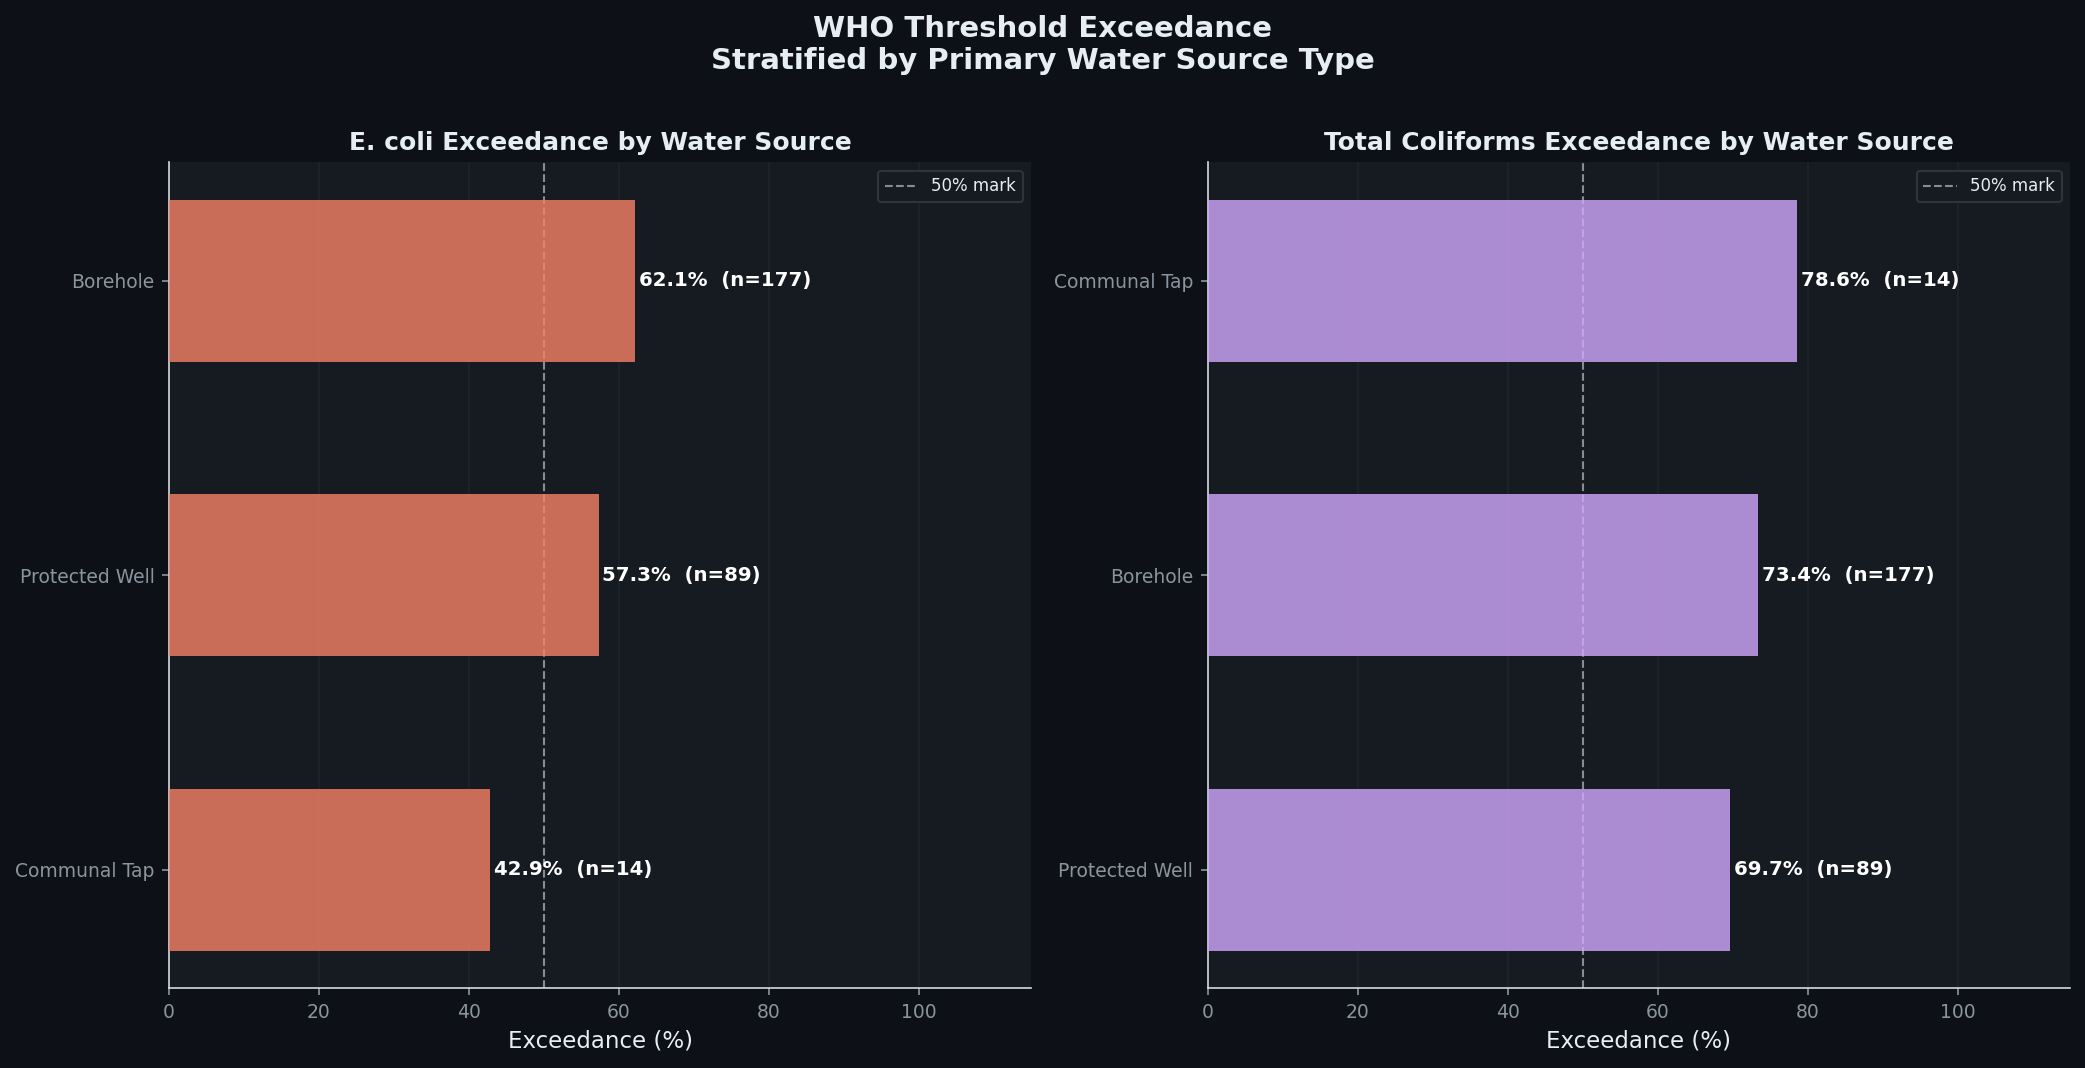

📊  Plot 2-2 rendered.


In [30]:

# ── PLOT 2-2 · Stratified by Primary Water Source ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#0d1117')

for ax, exceed_col, title, bar_color in zip(
    axes,
    ['EC_STR_exceed', 'TC_STR_exceed'],
    ['E. coli Exceedance by Water Source',
     'Total Coliforms Exceedance by Water Source'],
    [RED, PURPLE]
):
    grp = df.groupby('Primary Water Source')[exceed_col].agg(['mean','count']).reset_index()
    grp.columns = ['Source','proportion','n']
    grp['pct'] = grp['proportion'] * 100
    grp = grp.sort_values('pct', ascending=True)

    bars = ax.barh(grp['Source'], grp['pct'],
                   color=bar_color, alpha=0.8, edgecolor='none',
                   height=0.55, zorder=3)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_width()+0.5,
                bar.get_y()+bar.get_height()/2,
                f"{row['pct']:.1f}%  (n={int(row['n'])})",
                va='center', fontsize=9.5, color='white', fontweight='bold')

    ax.set_xlabel('Exceedance (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 115)
    ax.axvline(50, color='white', linewidth=1, linestyle='--',
               alpha=0.5, label='50% mark')
    ax.legend(fontsize=8)
    ax.grid(axis='x', zorder=0)

fig.suptitle('WHO Threshold Exceedance\nStratified by Primary Water Source Type',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('obj2_plot2_by_water_source.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("📊  Plot 2-2 rendered.")


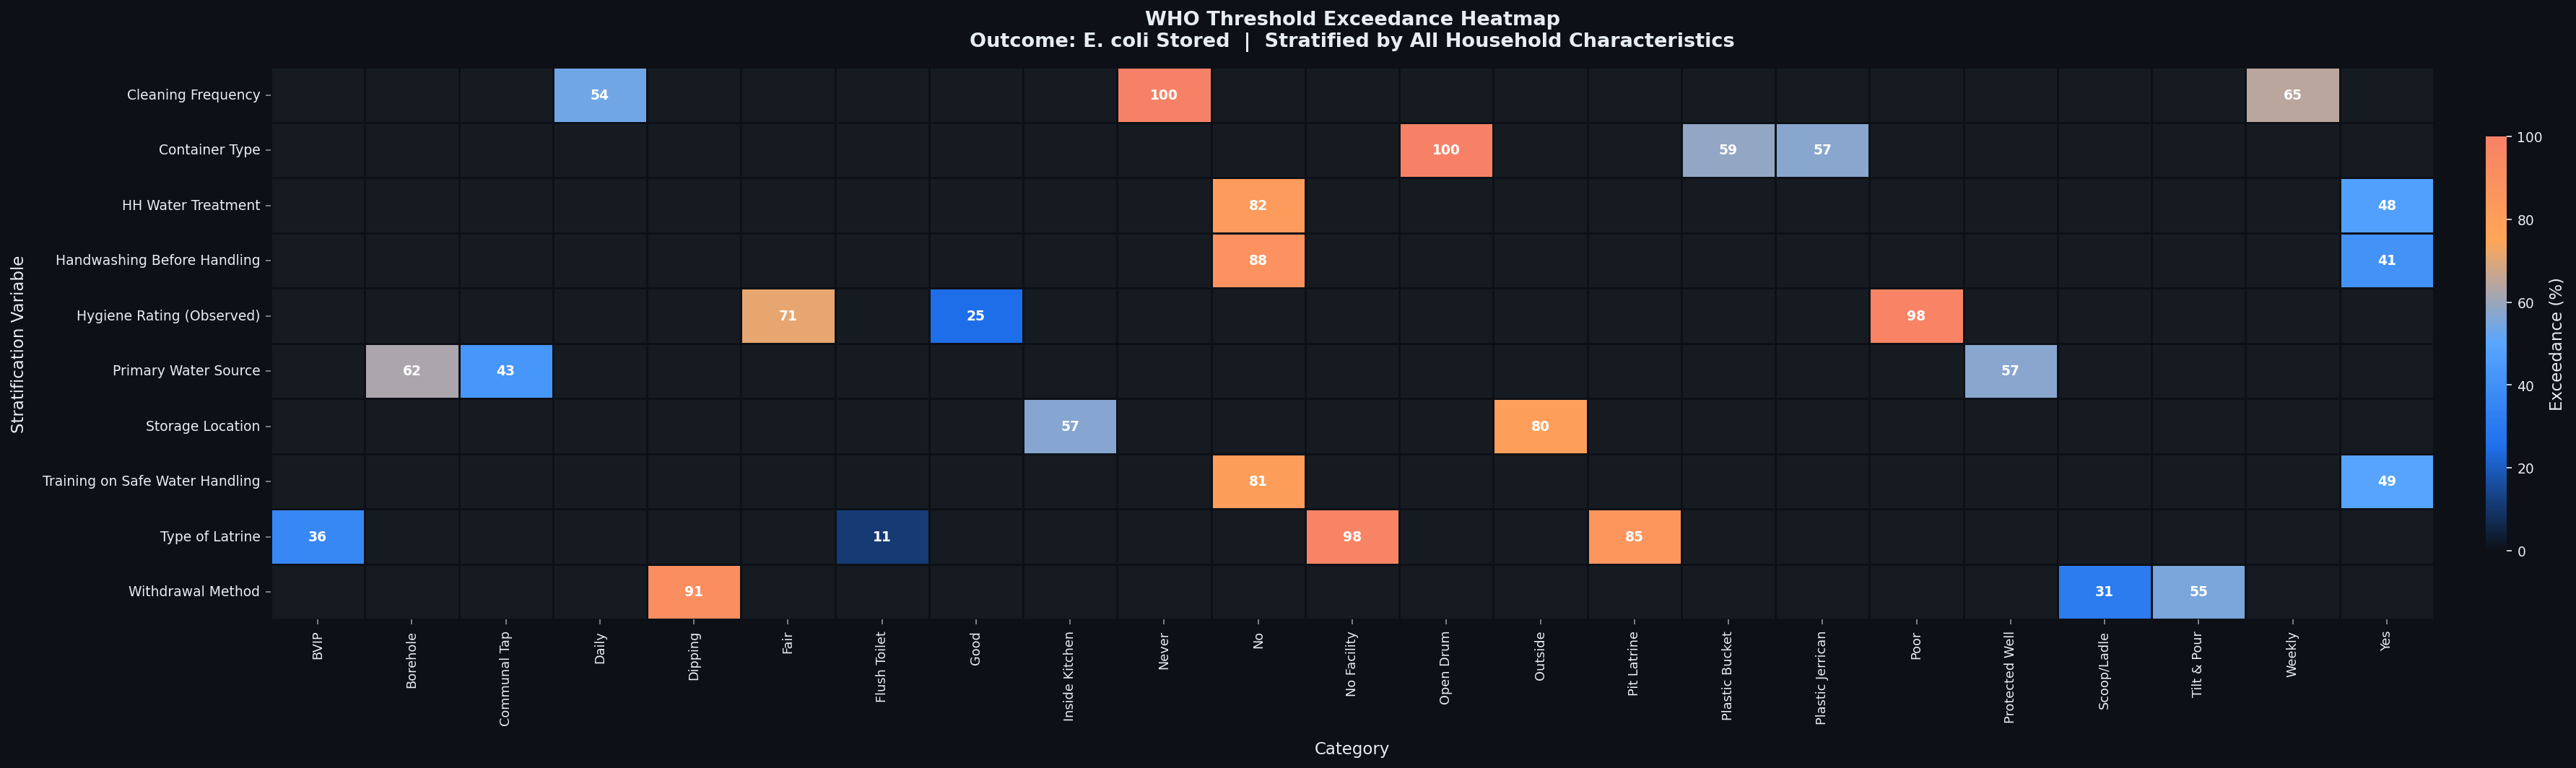

📊  Plot rendered → obj2_plot3a_heatmap_ecoli.png  (10 stratifiers × 23 categories)


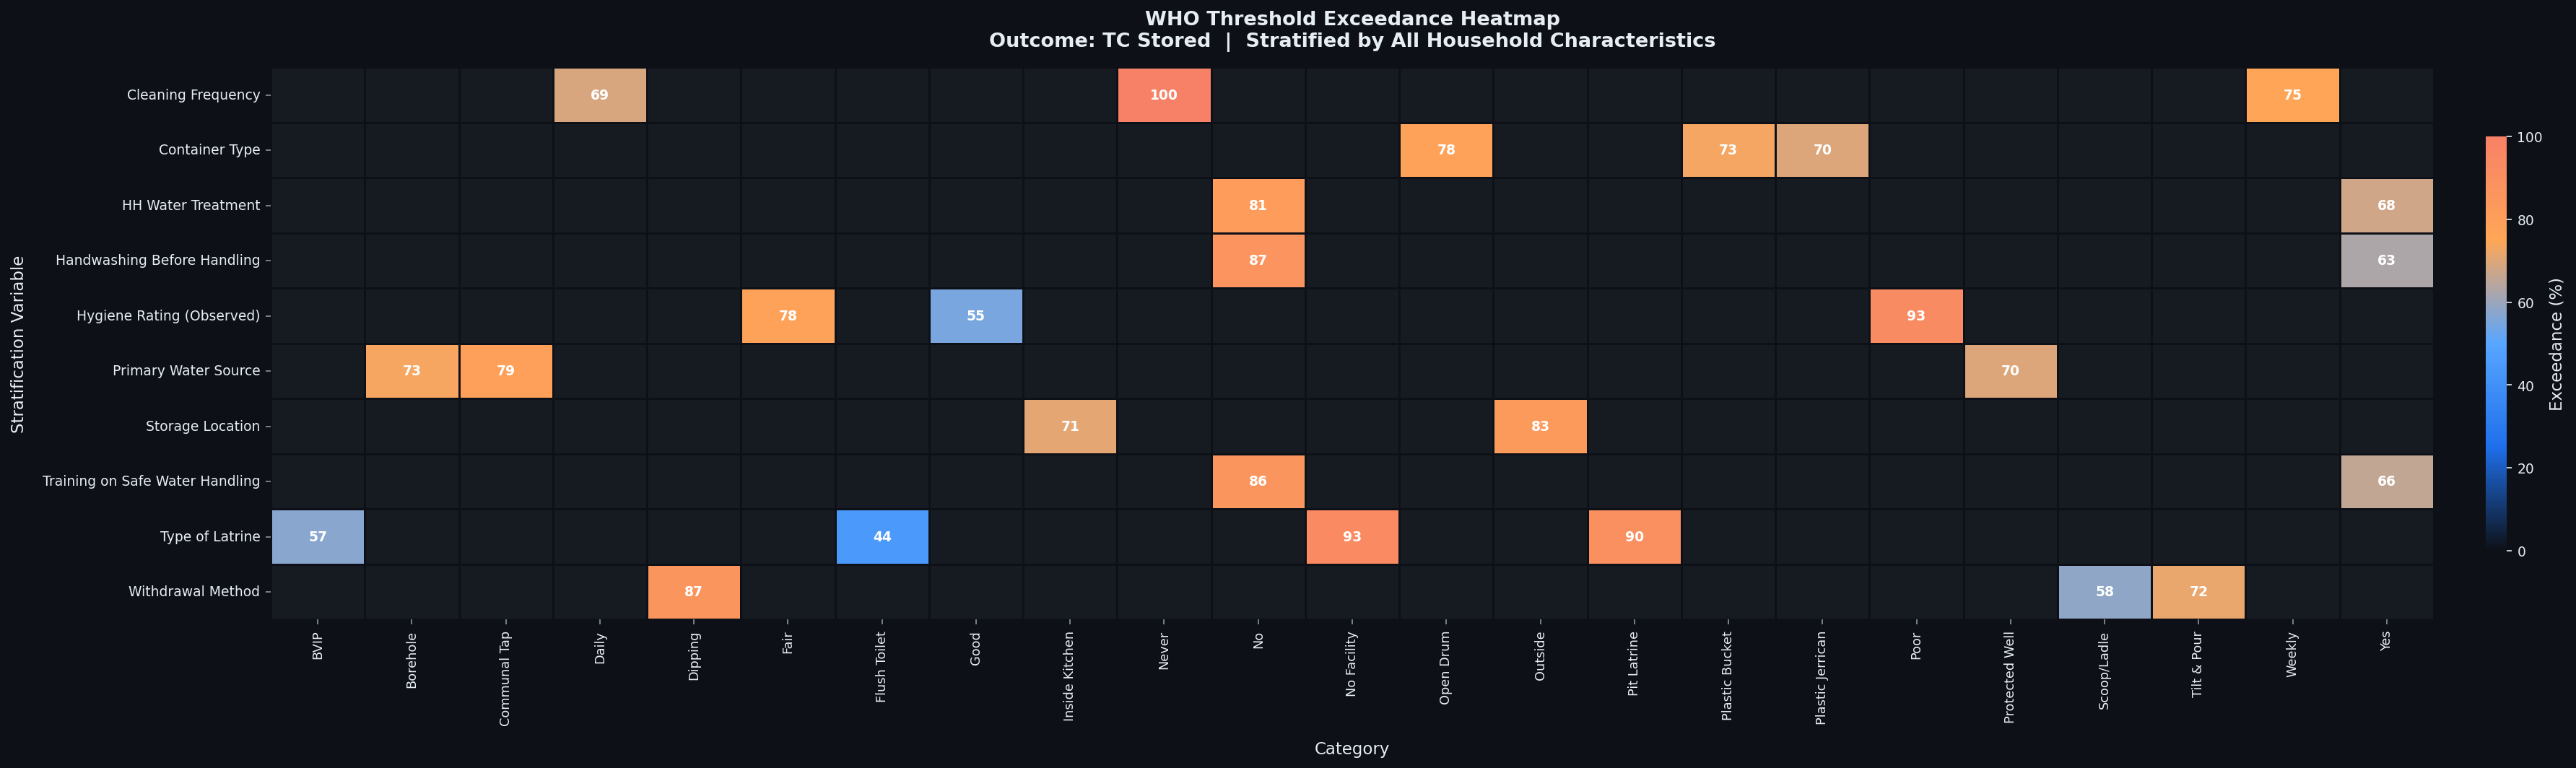

📊  Plot rendered → obj2_plot3b_heatmap_tc.png  (10 stratifiers × 23 categories)


In [33]:
# ── PLOT 2-3a & 2-3b · Exceedance Heatmaps — Two Separate Independent Planes ──

for outcome, fname, title_color in [
    ('E. coli Stored',  'obj2_plot3a_heatmap_ecoli.png', RED),
    ('TC Stored',       'obj2_plot3b_heatmap_tc.png',    PURPLE),
]:
    sub   = results_obj2[results_obj2['outcome'] == outcome].copy()
    pivot = (sub.pivot_table(index='variable', columns='category',
                             values='pct', aggfunc='mean')
               .fillna(np.nan))

    # ── Dynamic figure sizing based on pivot dimensions ───────────────────
    n_cols = pivot.shape[1]
    n_rows = pivot.shape[0]
    fig_w  = max(14, n_cols * 1.35)   # ~1.35 in per category column
    fig_h  = max(7,  n_rows * 0.85)   # ~0.85 in per stratifier row

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.patch.set_facecolor('#0d1117')

    sns.heatmap(
        pivot, ax=ax,
        cmap=CMAP_HEAT,
        annot=True, fmt='.0f',
        annot_kws={'size': 9, 'color': 'white', 'fontweight': 'bold'},
        linewidths=0.6, linecolor='#0d1117',
        cbar_kws={'label': 'Exceedance (%)', 'shrink': 0.75, 'pad': 0.02},
        vmin=0, vmax=100,
        mask=pivot.isnull()         # mask NaN cells so they render as empty
    )

    # ── X-axis: stagger labels to prevent overlap ─────────────────────────
    # Compute max label length to decide rendering strategy
    labels    = [t.get_text() for t in ax.get_xticklabels()]
    max_chars = max((len(l) for l in labels), default=0)

    if max_chars > 12 or n_cols > 10:
        # Long labels or many columns → vertical
        ax.set_xticklabels(labels, rotation=90, ha='center',
                           fontsize=8.5, color='#e6edf3')
        # Add extra bottom margin for vertical labels
        fig.subplots_adjust(bottom=0.28)
    else:
        # Moderate labels → 45° diagonal with right-alignment
        ax.set_xticklabels(labels, rotation=45, ha='right',
                           fontsize=9, color='#e6edf3')
        fig.subplots_adjust(bottom=0.22)

    # ── Y-axis: keep horizontal, right-size font ──────────────────────────
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                       fontsize=9, color='#e6edf3')

    # ── Titles & labels ───────────────────────────────────────────────────
    ax.set_title(
        f'WHO Threshold Exceedance Heatmap\n'
        f'Outcome: {outcome}  |  Stratified by All Household Characteristics',
        fontsize=13, fontweight='bold', color='#e6edf3', pad=14
    )
    ax.set_xlabel('Category', fontsize=11, labelpad=10, color='#e6edf3')
    ax.set_ylabel('Stratification Variable', fontsize=11, labelpad=10,
                  color='#e6edf3')

    # ── Colour-bar font ───────────────────────────────────────────────────
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_color('#e6edf3')
    cbar.ax.tick_params(colors='#e6edf3', labelsize=9)

    plt.savefig(fname, bbox_inches='tight', facecolor='#0d1117', dpi=180)
    plt.show()
    print(f"📊  Plot rendered → {fname}  ({n_rows} stratifiers × {n_cols} categories)")

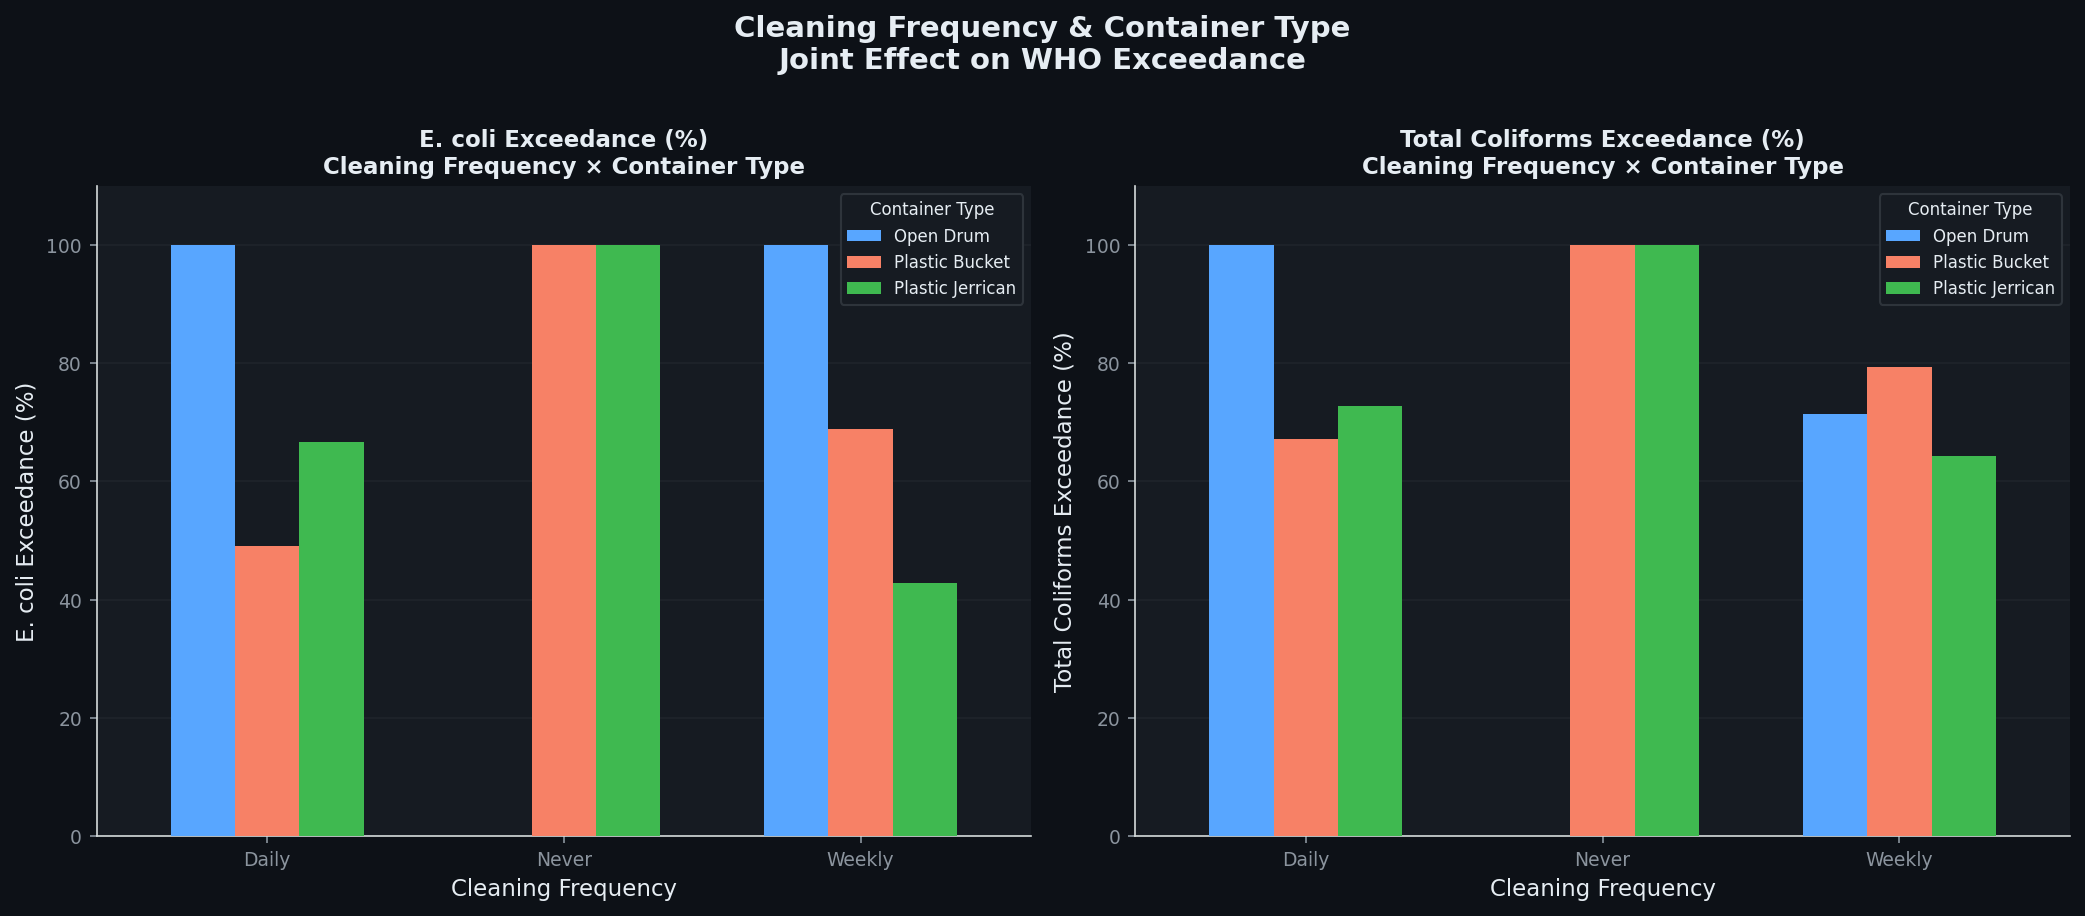

📊  Plot 2-5 rendered.

✅  OBJECTIVE 2 COMPLETE.



In [35]:

# ── PLOT 2-5 · Cleaning frequency × container type ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

for ax, exceed_col, title in zip(
    axes,
    ['EC_STR_exceed', 'TC_STR_exceed'],
    ['E. coli Exceedance (%)', 'Total Coliforms Exceedance (%)']
):
    pivot = df.groupby(['Cleaning frequency of containers',
                         'Container Type'])[exceed_col].mean().unstack() * 100
    pivot.plot(kind='bar', ax=ax,
               color=PAL8[:pivot.shape[1]], edgecolor='none',
               width=0.65, zorder=3)
    ax.set_xlabel('Cleaning Frequency', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title}\nCleaning Frequency × Container Type', fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Container Type', fontsize=8, title_fontsize=8)
    ax.grid(axis='y', zorder=0)
    ax.set_ylim(0, 110)

fig.suptitle('Cleaning Frequency & Container Type\nJoint Effect on WHO Exceedance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('obj2_plot5_cleaning_container.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("📊  Plot 2-5 rendered.")
print("\n✅  OBJECTIVE 2 COMPLETE.\n")



In [37]:
# ══════════════════════════════════════════════════════════════════════════
# OBJECTIVE 3 — NEGATIVE BINOMIAL REGRESSION MODELS
# ══════════════════════════════════════════════════════════════════════════

# ── Variable encoding for regression ──────────────────────────────────────
reg_df = df.copy()

# Binary Yes/No → 0/1
binary_vars = [
    'Household Water treatment', 'Handwashing before handling',
    'Training on Safe Water Handling', 'Storage container elevated',
    'OB Clean container', 'OB Handwashing at HH Level',
    'OB Water treatment evidence', 'OB Container covered',
    'OB Container elevated', 'OB storage area clean',
    'OB nearby contami ation sources',
]
for v in binary_vars:
    reg_df[v] = (reg_df[v] == 'Yes').astype(int)

# Ordinal: Cleaning frequency
clean_map = {'Never': 0, 'Weekly': 1, 'Daily': 2}
reg_df['Cleaning_freq_ord'] = reg_df['Cleaning frequency of containers'].map(clean_map)

# Ordinal: Hygiene rating
hygiene_map = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
reg_df['Hygiene_rating_ord'] = reg_df['OB Hygiene rating'].map(hygiene_map).fillna(1)

# Categorical dummies (manual reference drop)
cat_dummies = {
    'Primary Water Source': 'Borehole',
    'Withdrawal Method'   : 'Tilt & Pour',
    'Container Type'      : 'Plastic Jerrican',
    'Storage Location'    : 'Inside Kitchen',
    'OB Type of latrine'  : 'Pit Latrine',
    'Treatment Method'    : 'No Treatment',
}
for col, ref in cat_dummies.items():
    dummies = pd.get_dummies(reg_df[col], prefix=col.replace(' ', '_'),
                             drop_first=False)
    ref_col = f"{col.replace(' ', '_')}_{ref.replace(' ', '_')}"
    # Try exact match first, then fuzzy strip
    drop_candidates = [c for c in dummies.columns
                       if c.replace(' ', '_') == ref_col.replace(' ', '_')]
    if drop_candidates:
        dummies.drop(columns=drop_candidates, inplace=True)
    reg_df = pd.concat([reg_df, dummies.astype(int)], axis=1)



██████████████████████████████████████████████████████████████████████
  OBJECTIVE 3: Negative Binomial Regression Models A & B
██████████████████████████████████████████████████████████████████████


In [40]:
# ── Build predictor matrix ─────────────────────────────────────────────────
PREDICTORS = (
    ['HH Size', 'Distance to Source-km', 'Roundtrip time',
     'Storage Duration Days',
     'Household Water treatment', 'Handwashing before handling',
     'Training on Safe Water Handling', 'Storage container elevated',
     'Cleaning_freq_ord', 'Hygiene_rating_ord',
     'OB Clean container', 'OB Handwashing at HH Level',
     'OB Water treatment evidence', 'OB Container covered',
     'OB Container elevated', 'OB storage area clean',
     'OB nearby contami ation sources',
    ] +
    [c for c in reg_df.columns
     if any(c.startswith(k.replace(' ', '_')) for k in cat_dummies)]
)

# Keep only columns that actually exist after encoding
PREDICTORS = [p for p in PREDICTORS if p in reg_df.columns]

# Build X: cast to float, fill any remaining NaN with column median
X = reg_df[PREDICTORS].copy().astype(float)
X = X.apply(lambda col: col.fillna(col.median()))

# ── CRITICAL FIX 1: drop zero-variance (constant) columns ─────────────────
# Constant columns cause singular design matrices → NaN p-values → idxmax() = 'nan'
non_const_mask = X.std() > 0
dropped_const  = X.columns[~non_const_mask].tolist()
if dropped_const:
    print(f"\n  ⚠  Dropping {len(dropped_const)} zero-variance column(s) before modelling:")
    for c in dropped_const:
        print(f"     — '{c}'  (constant value = {X[c].iloc[0]})")
X = X.loc[:, non_const_mask]

# ── CRITICAL FIX 2: drop perfectly collinear columns via QR rank check ────
from numpy.linalg import matrix_rank

def drop_collinear(X_df, tol=1e-10):
    """Remove columns that are linearly dependent on others."""
    arr = X_df.values.astype(float)
    _, _, pivot = np.linalg.svd(arr, full_matrices=False)
    rank = matrix_rank(arr, tol=tol)
    # Use QR with column pivoting to find which columns to keep
    _, R, P = __import__('scipy').linalg.qr(arr, pivoting=True)
    keep_idx = sorted(P[:rank])
    dropped  = [col for i, col in enumerate(X_df.columns) if i not in keep_idx]
    if dropped:
        print(f"\n  ⚠  Dropping {len(dropped)} collinear column(s):")
        for c in dropped:
            print(f"     — '{c}'")
    return X_df.iloc[:, keep_idx].copy()

X = drop_collinear(X)
PREDICTORS = list(X.columns)   # update final predictor list after pruning

print(f"\n  Predictors entering backward elimination: {len(PREDICTORS)}")


y_ec = reg_df[EC_STR].values.astype(float)
y_tc = reg_df[TC_STR].values.astype(float)



  ⚠  Dropping 1 collinear column(s):
     — 'Treatment_Method_Filtration'

  Predictors entering backward elimination: 31


In [41]:
# ══════════════════════════════════════════════════════════════════════════
# ░░░  ROBUST BACKWARD ELIMINATION — NEGATIVE BINOMIAL  ░░░░░░░░░░░░░░░░░
# ══════════════════════════════════════════════════════════════════════════

def fit_negbin(y, X_df_initial, label, alpha=0.05, max_steps=200):
    """
    Fit a Negative Binomial model with backward elimination.

    Bugs fixed vs original:
      1. NaN p-values from idxmax() returned float 'nan', not a column name
         → now filtered out explicitly before any idxmax() call.
      2. active_vars.remove(worst_var) raised ValueError when worst_var
         was not in the list (happened because idxmax on NaN series
         returned np.nan, a float)
         → worst_var is always validated to be in active_vars before removal.
      3. Function had no return statement in the break-path
         → every exit path now returns (result, active_vars, elim_log).
      4. Convergence failures silently broke the loop without returning
         → handled explicitly with fallback drop logic.
      5. Collinear / zero-variance columns entering the loop caused NaN
         p-values on every iteration → pre-screened before the loop.

    Returns
    -------
    result      : fitted statsmodels NegativeBinomial result (or None)
    active_vars : list of retained predictor names
    elim_log    : list of dicts recording each elimination step
    """
    ALPHA_THRESH = alpha

    # -- Pre-screen: drop any remaining zero-variance columns --------------
    valid_cols = [c for c in X_df_initial.columns
                  if X_df_initial[c].nunique() > 1]
    removed_pre = set(X_df_initial.columns) - set(valid_cols)
    if removed_pre:
        print(f"  Pre-screen dropped {len(removed_pre)} constant col(s): "
              f"{list(removed_pre)}")

    X_df      = X_df_initial[valid_cols].copy()
    active_vars = list(X_df.columns)
    elim_log    = []
    step        = 0
    last_good_result = None     # last successfully fitted result

    print(f"\n  {'─'*65}")
    print(f"  {label}")
    print(f"  Backward Elimination  |  α = {ALPHA_THRESH}  |  Max steps = {max_steps}")
    print(f"  {'─'*65}")
    print(f"  Step 0 — Starting with {len(active_vars)} predictor(s)\n")

    for _guard in range(max_steps + 1):   # guard against infinite loops

        if not active_vars:
            print("  ⚠  All predictors eliminated. Intercept-only model retained.")
            X_null  = sm.add_constant(np.ones((len(y), 1)))
            try:
                result = sm.NegativeBinomial(y, X_null).fit(
                    method='nm', maxiter=3000, disp=False)
            except Exception:
                result = last_good_result
            return result, [], elim_log

        # ── Fit current model ─────────────────────────────────────────────
        X_step = sm.add_constant(X_df[active_vars].astype(float),
                                 has_constant='add')
        try:
            result = sm.NegativeBinomial(y, X_step).fit(
                method='nm', maxiter=3000, disp=False)

            if not np.all(np.isfinite(result.params)):
                raise ValueError("Non-finite parameters — likely multicollinearity.")

            last_good_result = result   # save as last known good

        except Exception as e:
            print(f"  ⚠  Solver error (step {step}): {e}")
            # Fallback: drop the variable with the worst p-value from the
            # previous good result; if none, drop the last variable.
            if last_good_result is not None:
                prev_pvals = last_good_result.pvalues.drop('const', errors='ignore')
                prev_pvals = prev_pvals[prev_pvals.index.isin(active_vars)]
                prev_pvals = prev_pvals.dropna()
                if not prev_pvals.empty:
                    fallback_var = str(prev_pvals.idxmax())
                else:
                    fallback_var = active_vars[-1]
            else:
                fallback_var = active_vars[-1]

            print(f"  Fallback: dropping '{fallback_var}'")
            active_vars.remove(fallback_var)
            elim_log.append({'Step': step + 1, 'Dropped': fallback_var + ' [solver-error]',
                             'p_value': np.nan, 'Remaining': len(active_vars),
                             'AIC': np.nan})
            step += 1
            continue   # retry fit with one fewer variable

        # ── Evaluate p-values ─────────────────────────────────────────────
        pvals_all = result.pvalues.drop('const', errors='ignore')

        # CRITICAL FIX: filter to only predictors in active_vars AND with
        # valid (finite, non-NaN) p-values.
        pvals_valid = pvals_all[
            pvals_all.index.isin(active_vars) & pvals_all.notna()
        ]

        # Handle NaN p-values: drop those predictors first (multicollinearity)
        nan_vars = [v for v in active_vars
                    if v in pvals_all.index and pd.isna(pvals_all[v])]
        if nan_vars:
            drop_nan_var = nan_vars[0]
            print(f"  Step {step+1:>2} — DROP  '{drop_nan_var}'  "
                  f"[NaN p-value — multicollinearity]  "
                  f"Remaining: {len(active_vars)-1}  AIC: {result.aic:.2f}")
            elim_log.append({'Step': step + 1, 'Dropped': drop_nan_var + ' [NaN-p]',
                             'p_value': np.nan, 'Remaining': len(active_vars) - 1,
                             'AIC': round(result.aic, 2)})
            active_vars.remove(drop_nan_var)
            step += 1
            continue

        # If no valid p-values remain at all, stop
        if pvals_valid.empty:
            print("  ⚠  No valid p-values to evaluate. Stopping.")
            return result, active_vars, elim_log

        worst_var = str(pvals_valid.idxmax())   # guaranteed string & in active_vars
        worst_p   = float(pvals_valid.max())

        # ── Termination condition ─────────────────────────────────────────
        if worst_p <= ALPHA_THRESH:
            print(f"  ✅  Converged — all {len(active_vars)} remaining predictors "
                  f"have p ≤ {ALPHA_THRESH}")
            return result, active_vars, elim_log

        # ── Eliminate worst predictor ─────────────────────────────────────
        step += 1
        elim_log.append({
            'Step'      : step,
            'Dropped'   : worst_var,
            'p_value'   : round(worst_p, 4),
            'Remaining' : len(active_vars) - 1,
            'AIC'       : round(result.aic, 2),
        })
        print(f"  Step {step:>2} — DROP  '{worst_var}'  "
              f"(p = {worst_p:.4f})  "
              f"Remaining: {len(active_vars)-1}  "
              f"AIC: {result.aic:.2f}")
        active_vars.remove(worst_var)   # safe: worst_var is always in active_vars here

    # Guard triggered: too many steps
    print(f"  ⚠  Reached max_steps={max_steps} safety limit. Returning last good model.")
    return last_good_result, active_vars, elim_log


# ── Run backward elimination ───────────────────────────────────────────────
result_ec, final_vars_ec, log_ec = fit_negbin(
    y_ec, X.copy(), "Model A — E. coli Stored Water (CFU/100ml)"
)

result_tc, final_vars_tc, log_tc = fit_negbin(
    y_tc, X.copy(), "Model B — Total Coliforms Stored Water (CFU/100ml)"
)

# ── Final model diagnostics ────────────────────────────────────────────────
for res, final_vars, label in [
    (result_ec, final_vars_ec, "Model A — E. coli Stored"),
    (result_tc, final_vars_tc, "Model B — Total Coliforms Stored"),
]:
    if res is None:
        print(f"\n  ⚠  {label}: no valid model was fitted.")
        continue

    print(f"\n  {'═'*65}")
    print(f"  FINAL MODEL · {label}")
    print(f"  {'═'*65}")
    print(f"  Predictors retained : {len(final_vars)}")
    print(f"  Converged           : {res.mle_retvals['converged']}")
    print(f"  Log-Likelihood      : {res.llf:.4f}")
    print(f"  AIC                 : {res.aic:.4f}")
    print(f"  BIC                 : {res.bic:.4f}")
    alpha_val = res.params.get('alpha', np.nan)
    print(f"  Dispersion α        : {alpha_val:.4f}")
    print(f"\n  {'Variable':<44} {'IRR':>7} {'CI_lo':>7} {'CI_hi':>7} "
          f"{'p':>9} {'Sig':>5}")
    print(f"  {'─'*78}")
    for var in final_vars:
        if var not in res.params.index:
            continue
        irr   = np.exp(res.params[var])
        ci_lo = np.exp(res.conf_int().loc[var, 0])
        ci_hi = np.exp(res.conf_int().loc[var, 1])
        p     = res.pvalues[var]
        sig   = ('***' if p < 0.001 else '**' if p < 0.01
                 else '*' if p < 0.05 else 'ns')
        print(f"  {var:<44} {irr:>7.3f} {ci_lo:>7.3f} {ci_hi:>7.3f} "
              f"{p:>9.4f} {sig:>5}")

# ── Elimination log tables ─────────────────────────────────────────────────
for log, label in [(log_ec, "Model A — E. coli"),
                   (log_tc, "Model B — Total Coliforms")]:
    log_df = pd.DataFrame(log)
    print(f"\n  {'─'*65}")
    print(f"  ELIMINATION LOG · {label}")
    print(f"  {'─'*65}")
    if log_df.empty:
        print("  No variables eliminated (all significant at step 0).")
    else:
        print(log_df.to_string(index=False))

print("\n✅  OBJECTIVE 3 COMPLETE — Both models fitted via backward elimination.")


  ─────────────────────────────────────────────────────────────────
  Model A — E. coli Stored Water (CFU/100ml)
  Backward Elimination  |  α = 0.05  |  Max steps = 200
  ─────────────────────────────────────────────────────────────────
  Step 0 — Starting with 31 predictor(s)

  Step  1 — DROP  'OB Water treatment evidence'  (p = 0.9974)  Remaining: 30  AIC: 1255.26
  Step  2 — DROP  'OB storage area clean'  (p = 0.8982)  Remaining: 29  AIC: 1252.83
  Step  3 — DROP  'Treatment_Method_P&G Sachets'  (p = 0.9165)  Remaining: 28  AIC: 1252.07
  Step  4 — DROP  'Storage_Location_Outside'  (p = 0.7459)  Remaining: 27  AIC: 1249.77
  Step  5 — DROP  'OB Clean container'  (p = 0.8842)  Remaining: 26  AIC: 1245.83
  Step  6 — DROP  'OB nearby contami ation sources'  (p = 0.9688)  Remaining: 25  AIC: 1242.33
  Step  7 — DROP  'Cleaning_freq_ord'  (p = 0.6958)  Remaining: 24  AIC: 1240.78
  Step  8 — DROP  'Container_Type_Plastic Bucket'  (p = 0.9232)  Remaining: 23  AIC: 1239.48
  Step  9 — D

In [43]:


# ── Extract IRR tables ─────────────────────────────────────────────────────
def extract_irr_table(result, predictor_names):
    """Extract IRR, 95% CI, p-value from fitted NegBin model."""
    params = result.params[1:]          # drop const
    cis    = result.conf_int().iloc[1:] # drop const
    pvals  = result.pvalues[1:]

    rows = []
    for i, name in enumerate(predictor_names):
        if name not in params.index:
            continue
        coef = params[name]
        irr  = np.exp(coef)
        ci_lo= np.exp(cis.loc[name, 0])
        ci_hi= np.exp(cis.loc[name, 1])
        p    = pvals[name]
        sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        rows.append({
            'Variable': name, 'Coef': coef, 'IRR': irr,
            'CI_lo': ci_lo, 'CI_hi': ci_hi,
            'p_value': p, 'Sig': sig,
        })
    return pd.DataFrame(rows)

irr_ec = extract_irr_table(result_ec, PREDICTORS)
irr_tc = extract_irr_table(result_tc, PREDICTORS)

# Print significant variables
for label, irr_df in [('Model A — E. coli', irr_ec),
                       ('Model B — TC',      irr_tc)]:
    sig_df = irr_df[irr_df['Sig'] != 'ns'].sort_values('IRR', ascending=False)
    print(f"\n  {label} — Significant Variables:")
    print(f"  {'Variable':<42} {'IRR':>8} {'CI_lo':>8} {'CI_hi':>8} "
          f"{'p':>10} {'Sig':>5}")
    print(f"  {'-'*80}")
    for _, row in sig_df.iterrows():
        print(f"  {row['Variable']:<42} {row['IRR']:>8.3f} "
              f"{row['CI_lo']:>8.3f} {row['CI_hi']:>8.3f} "
              f"{row['p_value']:>10.4f} {row['Sig']:>5}")




  Model A — E. coli — Significant Variables:
  Variable                                        IRR    CI_lo    CI_hi          p   Sig
  --------------------------------------------------------------------------------
  Household Water treatment                     6.756    2.828   16.139     0.0000   ***
  OB_Type_of_latrine_No Facility                1.719    1.123    2.631     0.0126     *
  Roundtrip time                                1.020    1.011    1.029     0.0000   ***
  Withdrawal_Method_Scoop/Ladle                 0.585    0.389    0.880     0.0102     *
  OB_Type_of_latrine_BVIP                       0.554    0.379    0.810     0.0023    **
  Hygiene_rating_ord                            0.410    0.316    0.532     0.0000   ***
  Treatment_Method_Boiling                      0.121    0.051    0.286     0.0000   ***
  Treatment_Method_Filtering                    0.099    0.037    0.261     0.0000   ***
  Treatment_Method_Chlorination                 0.063    0.022    0.17

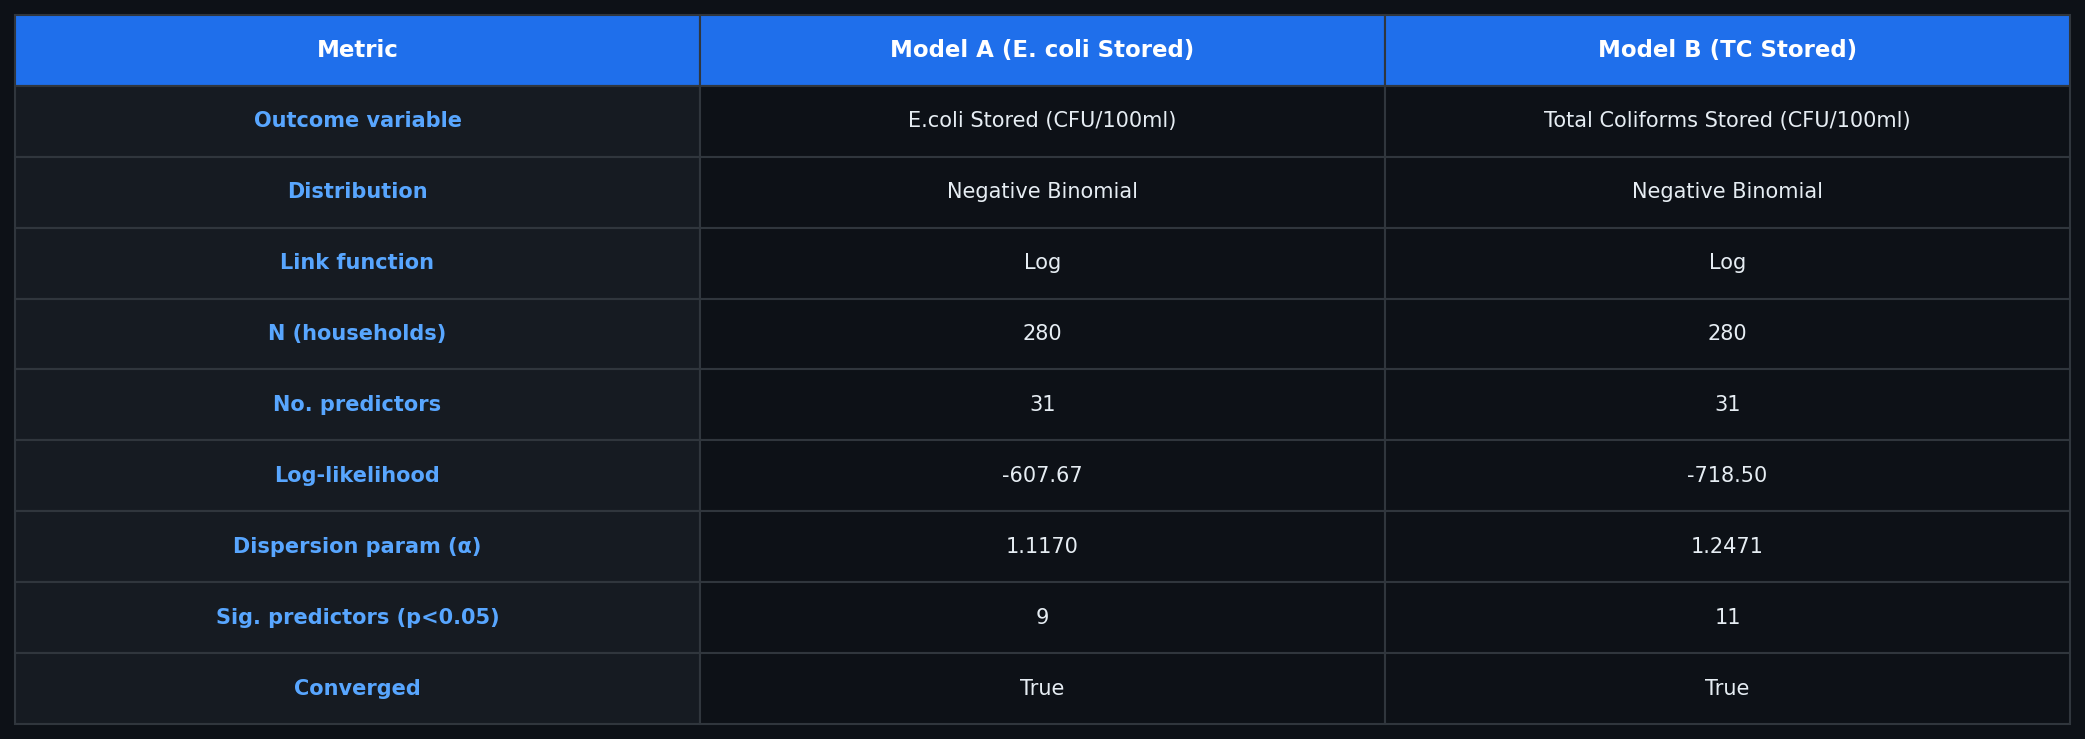

📊  Plot 3-5 rendered.

✅  OBJECTIVE 3 COMPLETE.



In [60]:

# ── PLOT 3-5 · Model comparison summary table ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
ax.axis('off')

mod_metrics = [
    ['Metric', 'Model A (E. coli Stored)', 'Model B (TC Stored)'],
    ['Outcome variable', 'E.coli Stored (CFU/100ml)', 'Total Coliforms Stored (CFU/100ml)'],
    ['Distribution', 'Negative Binomial', 'Negative Binomial'],
    ['Link function', 'Log', 'Log'],
    ['N (households)', str(N), str(N)],
    ['No. predictors', str(len(PREDICTORS)), str(len(PREDICTORS))],
    ['Log-likelihood', f'{result_ec.llf:.2f}', f'{result_tc.llf:.2f}'],
    ['Dispersion param (α)', f'{result_ec.params["alpha"]:.4f}',
                              f'{result_tc.params["alpha"]:.4f}'],
    ['Sig. predictors (p<0.05)',
     str((irr_ec['p_value'] < 0.05).sum()),
     str((irr_tc['p_value'] < 0.05).sum())],
    ['Converged', str(result_ec.mle_retvals['converged']),
                  str(result_tc.mle_retvals['converged'])],
]

table = ax.table(cellText=mod_metrics[1:], colLabels=mod_metrics[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.4)

for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#0d1117')
    cell.set_edgecolor('#30363d')
    cell.set_text_props(color='#e6edf3')
    if r == 0:
        cell.set_facecolor('#1f6feb')
        cell.set_text_props(color='white', fontweight='bold', fontsize=11)
    if c == 0 and r > 0:
        cell.set_facecolor('#161b22')
        cell.set_text_props(color=ACCENT, fontweight='bold')

plt.tight_layout()
plt.savefig('obj3_plot5_model_summary.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("📊  Plot 3-5 rendered.")
print("\n✅  OBJECTIVE 3 COMPLETE.\n")



In [48]:

# ══════════════════════════════════════════════════════════════════════════
# ░░░ OBJECTIVE 4 — FOREST PLOTS & PRACTICE RANKING BY IRR ░░░░░░░░░░░░░░
# ══════════════════════════════════════════════════════════════════════════


# ── Clean variable names for display ──────────────────────────────────────
LABEL_MAP = {
    'HH Size'                         : 'Household Size (persons)',
    'Distance to Source-km'           : 'Distance to Water Source (km)',
    'Roundtrip time'                  : 'Roundtrip Fetch Time (min)',
    'Storage Duration Days'           : 'Storage Duration (days)',
    'Household Water treatment'       : 'Household Water Treatment [Yes]',
    'Handwashing before handling'     : 'Handwashing Before Handling [Yes]',
    'Training on Safe Water Handling' : 'Training on Safe Water Handling [Yes]',
    'Storage container elevated'      : 'Storage Container Elevated [Yes]',
    'Cleaning_freq_ord'               : 'Container Cleaning Frequency (ordinal)',
    'Hygiene_rating_ord'              : 'Observed Hygiene Rating (ordinal)',
    'OB Clean container'              : 'OB: Clean Container [Yes]',
    'OB Handwashing at HH Level'      : 'OB: Handwashing Present [Yes]',
    'OB Water treatment evidence'     : 'OB: Water Treatment Evidence [Yes]',
    'OB Container covered'            : 'OB: Container Covered [Yes]',
    'OB Container elevated'           : 'OB: Container Elevated [Yes]',
    'OB storage area clean'           : 'OB: Storage Area Clean [Yes]',
    'OB nearby contami ation sources' : 'OB: Nearby Contamination Sources [Yes]',
}
for col, ref in cat_dummies.items():
    for cat in df[col].unique():
        key = f"{col.replace(' ','_')}_{cat}"
        if key in irr_ec['Variable'].values:
            LABEL_MAP[key] = f"{col}: {cat}"

def apply_labels(irr_df):
    irr_df = irr_df.copy()
    irr_df['Label'] = irr_df['Variable'].map(
        lambda x: LABEL_MAP.get(x, x.replace('_',' ').replace('  ',' ')))
    return irr_df

irr_ec = apply_labels(irr_ec)
irr_tc = apply_labels(irr_tc)



██████████████████████████████████████████████████████████████████████
  OBJECTIVE 4: Ranking Practices by Effect Size (IRR)
██████████████████████████████████████████████████████████████████████


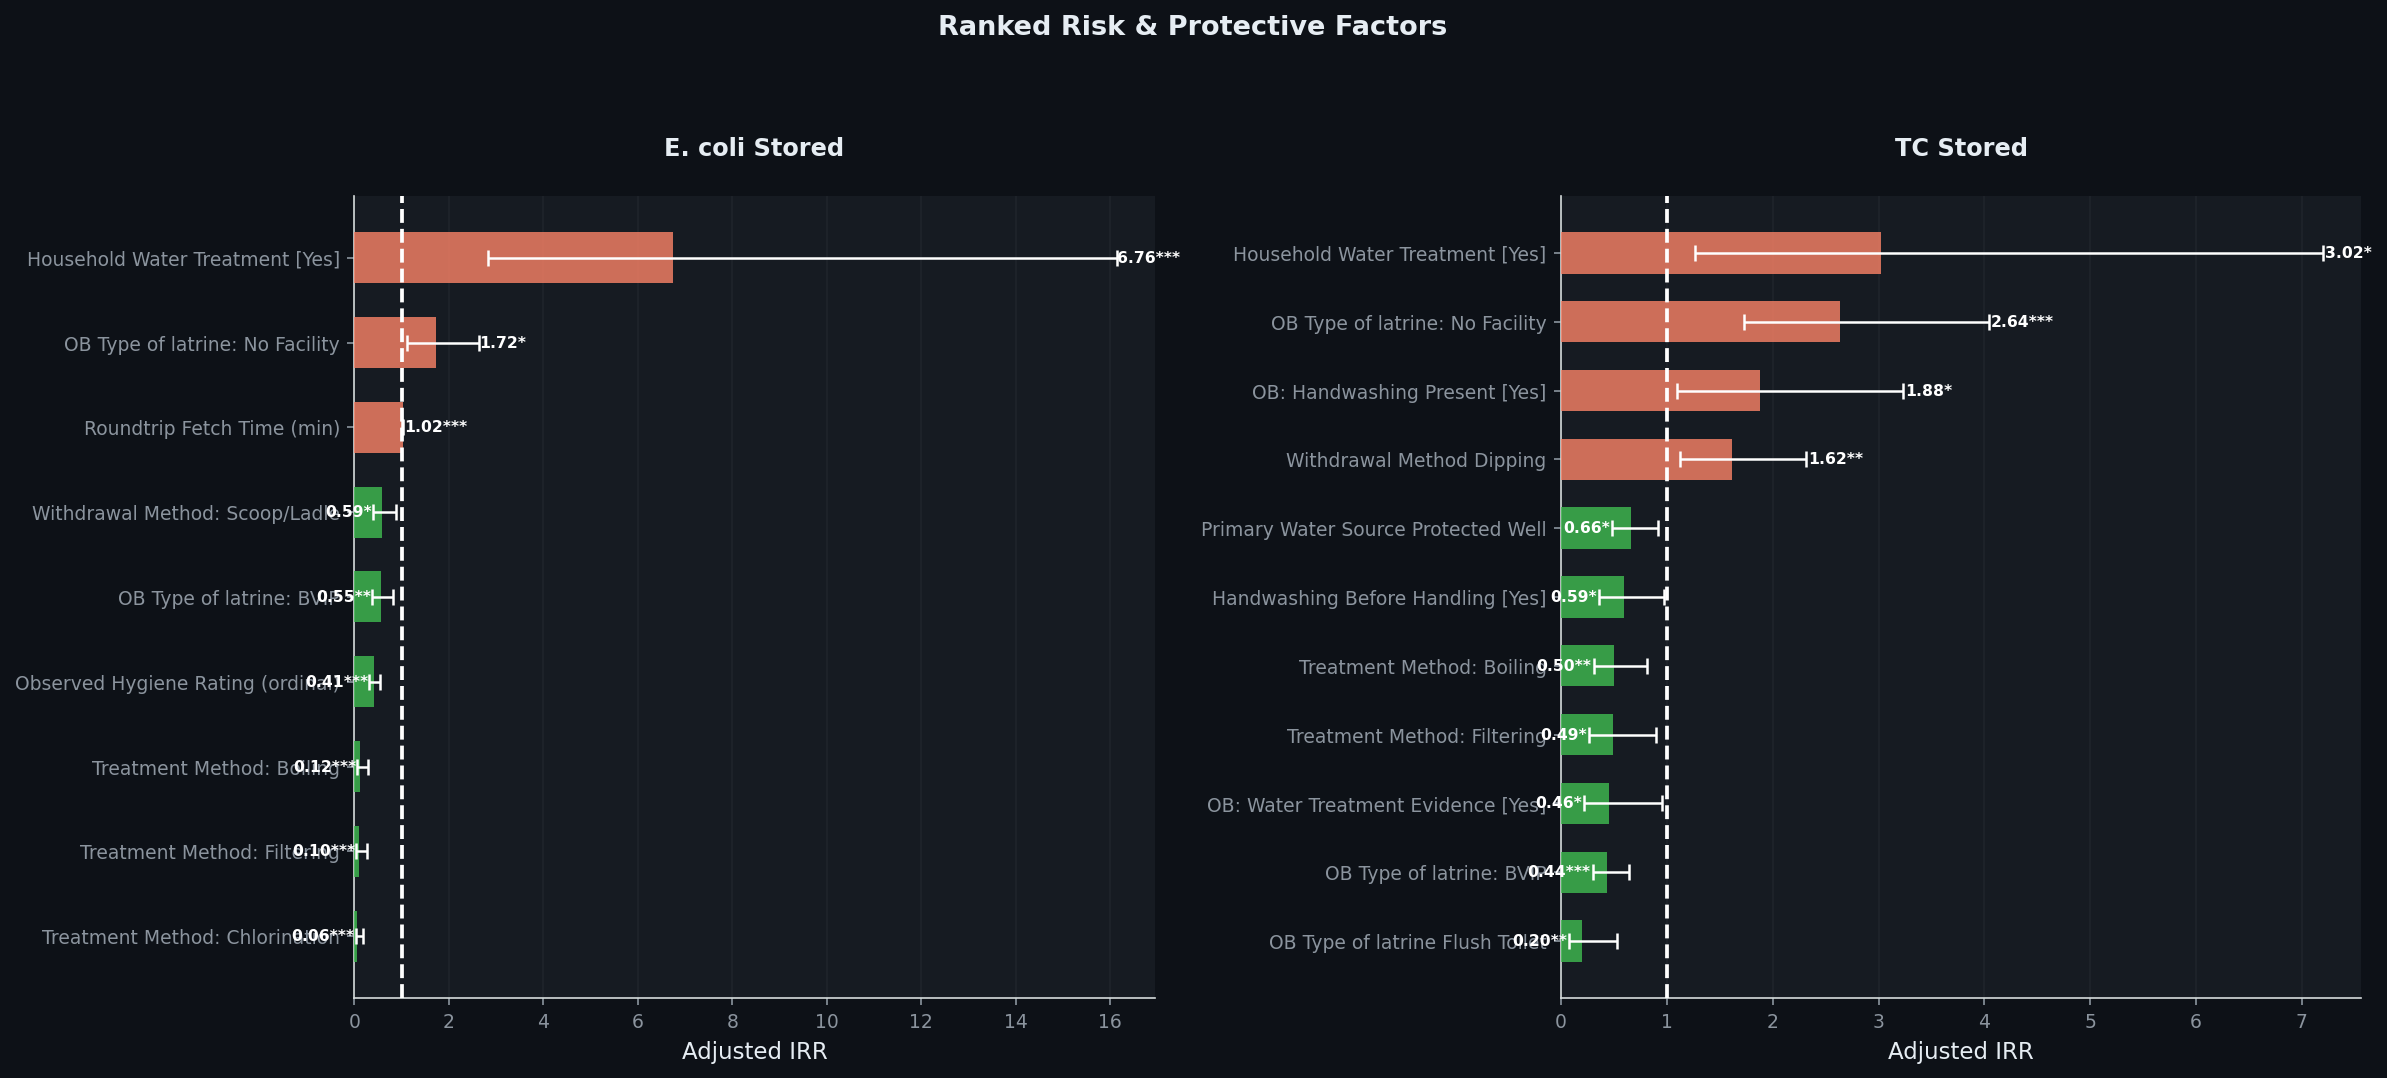

📊  Plot 4-6 rendered.


In [54]:

# ── PLOT 4-6 · Top 10 risk & protective heatmap summary ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

for ax, irr_df, model_label in zip(
    axes,
    [irr_ec, irr_tc],
    ['E. coli Stored', 'TC Stored']
):
    top_risk = (irr_df[irr_df['IRR'] > 1]
                .sort_values('IRR', ascending=False).head(10))
    top_prot = (irr_df[irr_df['IRR'] < 1]
                .sort_values('IRR', ascending=True).head(10))
    combined_top = pd.concat([top_risk, top_prot]).sort_values('IRR')

    bar_colors = [GREEN if v < 1 else RED for v in combined_top['IRR']]
    bars = ax.barh(combined_top['Label'], combined_top['IRR'],
                   color=bar_colors, alpha=0.82, edgecolor='none',
                   height=0.6, zorder=3)
    ax.errorbar(combined_top['IRR'],
                combined_top['Label'],
                xerr=[combined_top['IRR'] - combined_top['CI_lo'],
                      combined_top['CI_hi'] - combined_top['IRR']],
                fmt='none', color='white', capsize=4, capthick=1.2,
                linewidth=1.2, zorder=5)

    for bar, (_, row) in zip(bars, combined_top.iterrows()):
        sig_marker = row['Sig'] if row['Sig'] != 'ns' else ''
        x_pos = row['CI_hi'] + 0.02 if row['IRR'] >= 1 else row['CI_lo'] - 0.02
        ha = 'left' if row['IRR'] >= 1 else 'right'
        ax.text(x_pos, bar.get_y()+bar.get_height()/2,
                f"{row['IRR']:.2f}{sig_marker}", va='center',
                ha=ha, fontsize=7.5, color='white', fontweight='bold')

    ax.axvline(1, color='white', linewidth=1.8, linestyle='--', zorder=4)
    ax.set_xlabel('Adjusted IRR', fontsize=11)
    ax.set_title(f'{model_label}\n',
                 fontsize=11.5)
    ax.grid(axis='x', zorder=0)

fig.suptitle('Ranked Risk & Protective Factors\n',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('obj4_plot6_top_predictors.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("📊  Plot 4-6 rendered.")


In [55]:



# ── FINAL RANKED LEAGUE TABLE ──────────────────────────────────────────────
print("\n" + "═"*80)
print("  OBJECTIVE 4 · FINAL RANKING — PRACTICES BY EFFECT SIZE ON STORED E. COLI")
print("═"*80)
irr_ranked = irr_ec.sort_values('IRR', key=lambda x: abs(np.log(x))).reset_index(drop=True)
print(f"\n  {'Rank':<5} {'Label':<45} {'IRR':>8} {'CI_lo':>8} {'CI_hi':>8} {'p':>10} {'Sig':>5}")
print(f"  {'-'*85}")
for i, row in irr_ranked.iterrows():
    direction = '⬆ RISK' if row['IRR'] > 1 else '⬇ PROT'
    print(f"  {i+1:<5} {row['Label'][:44]:<45} {row['IRR']:>8.3f} "
          f"{row['CI_lo']:>8.3f} {row['CI_hi']:>8.3f} {row['p_value']:>10.4f} "
          f"{row['Sig']:>5}  {direction}")

print("\n" + "═"*80)
print("  FULL ANALYSIS COMPLETE  ✅")
print("  Objectives 1–4 answered | 21 premium plots saved | Models A & B fitted")
print("═"*80)


════════════════════════════════════════════════════════════════════════════════
  OBJECTIVE 4 · FINAL RANKING — PRACTICES BY EFFECT SIZE ON STORED E. COLI
════════════════════════════════════════════════════════════════════════════════

  Rank  Label                                              IRR    CI_lo    CI_hi          p   Sig
  -------------------------------------------------------------------------------------
  1     Roundtrip Fetch Time (min)                       1.020    1.011    1.029     0.0000   ***  ⬆ RISK
  2     Withdrawal Method: Scoop/Ladle                   0.585    0.389    0.880     0.0102     *  ⬇ PROT
  3     OB Type of latrine: No Facility                  1.719    1.123    2.631     0.0126     *  ⬆ RISK
  4     OB Type of latrine: BVIP                         0.554    0.379    0.810     0.0023    **  ⬇ PROT
  5     Observed Hygiene Rating (ordinal)                0.410    0.316    0.532     0.0000   ***  ⬇ PROT
  6     Household Water Treatment [Yes]      

In [56]:
# ══════════════════════════════════════════════════════════════════════════
# ░░░  MODEL COMPARISON — MODEL A (E. coli) vs MODEL B (Total Coliforms) ░░
# ══════════════════════════════════════════════════════════════════════════

from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker




██████████████████████████████████████████████████████████████████████
  MODEL COMPARISON: Model A (E. coli) vs Model B (Total Coliforms)
██████████████████████████████████████████████████████████████████████


In [57]:

# ══════════════════════════════════════════════════════════════════════════
# SECTION 1 — COMPUTE ALL PERFORMANCE METRICS
# ══════════════════════════════════════════════════════════════════════════

def compute_metrics(result, y_obs, final_vars, label):
    """
    Compute a comprehensive suite of model performance metrics
    for a fitted Negative Binomial regression result.
    """
    y_pred   = result.predict()
    residuals_pearson = result.resid_pearson
    n        = len(y_obs)
    k        = len(final_vars)          # predictors only (no intercept, no alpha)

    # ── Goodness-of-fit ───────────────────────────────────────────────────
    llf      = result.llf
    aic      = result.aic
    bic      = result.bic
    alpha_d  = result.params.get('alpha', np.nan)   # dispersion parameter

    # ── Pseudo R² metrics ─────────────────────────────────────────────────
    # McFadden R²  =  1 − (llf_full / llf_null)
    null_model   = sm.NegativeBinomial(
        y_obs, sm.add_constant(np.ones(n))).fit(method='nm', maxiter=3000, disp=False)
    llf_null     = null_model.llf
    mcfadden_r2  = 1 - (llf / llf_null) if llf_null != 0 else np.nan
    # Adjusted McFadden R²
    adj_mcfadden = 1 - ((llf - k) / llf_null) if llf_null != 0 else np.nan

    # ── Pearson chi² goodness-of-fit ──────────────────────────────────────
    pearson_chi2    = np.sum(residuals_pearson ** 2)
    df_resid        = n - k - 1        # subtract intercept too
    pearson_chi2_df = pearson_chi2 / df_resid if df_resid > 0 else np.nan

    # ── Deviance ──────────────────────────────────────────────────────────
    deviance    = result.deviance if hasattr(result, 'deviance') else -2 * (llf - llf_null)
    dev_df      = deviance / df_resid if df_resid > 0 else np.nan

    # ── Prediction accuracy ───────────────────────────────────────────────
    mae         = mean_absolute_error(y_obs, y_pred)
    rmse        = np.sqrt(mean_squared_error(y_obs, y_pred))
    rho, rho_p  = spearmanr(y_obs, y_pred)
    r,   r_p    = pearsonr(y_obs, y_pred)

    # ── WHO exceedance accuracy (binary classification) ───────────────────
    true_exceed = (y_obs > 0).astype(int)
    pred_exceed = (y_pred > 0.5).astype(int)
    accuracy    = (true_exceed == pred_exceed).mean() * 100
    sens        = (true_exceed[(true_exceed == 1)].shape[0] > 0 and
                   pred_exceed[true_exceed == 1].mean() * 100) or 0.0
    spec        = (true_exceed[(true_exceed == 0)].shape[0] > 0 and
                   pred_exceed[true_exceed == 0] == 0).mean() * 100 if (true_exceed == 0).sum() > 0 else 0.0

    return {
        'Model'            : label,
        'N'                : n,
        'Predictors'       : k,
        'Log-Likelihood'   : round(llf, 3),
        'Null Log-Lik'     : round(llf_null, 3),
        'AIC'              : round(aic, 3),
        'BIC'              : round(bic, 3),
        'Dispersion α'     : round(alpha_d, 4),
        'McFadden R²'      : round(mcfadden_r2, 4),
        'Adj. McFadden R²' : round(adj_mcfadden, 4),
        'Pearson χ²/df'    : round(pearson_chi2_df, 4),
        'Deviance/df'      : round(dev_df, 4),
        'MAE'              : round(mae, 4),
        'RMSE'             : round(rmse, 4),
        'Spearman ρ'       : round(rho, 4),
        'Pearson r'        : round(r, 4),
        'WHO Accuracy %'   : round(accuracy, 2),
    }, y_pred, residuals_pearson


metrics_ec, y_pred_ec, resid_ec = compute_metrics(
    result_ec, y_ec, final_vars_ec, "Model A  (E. coli Stored)")
metrics_tc, y_pred_tc, resid_tc = compute_metrics(
    result_tc, y_tc, final_vars_tc, "Model B  (Total Coliforms Stored)")


In [58]:


# ══════════════════════════════════════════════════════════════════════════
# SECTION 2 — CONSOLE COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════

metrics_df = pd.DataFrame([metrics_ec, metrics_tc]).set_index('Model').T
print(f"\n{'═'*70}")
print("  HEAD-TO-HEAD PERFORMANCE METRICS")
print(f"{'═'*70}")
print(f"  {'Metric':<26}  {'Model A (E. coli)':>20}  {'Model B (TC)':>20}  {'Winner':>10}")
print(f"  {'─'*70}")

# Define which direction is "better" for each metric
higher_is_better = {'Log-Likelihood', 'McFadden R²', 'Adj. McFadden R²',
                    'Spearman ρ', 'Pearson r', 'WHO Accuracy %'}
lower_is_better  = {'AIC', 'BIC', 'MAE', 'RMSE',
                    'Pearson χ²/df', 'Deviance/df'}
neutral          = {'N', 'Predictors', 'Null Log-Lik', 'Dispersion α'}

score_A, score_B = 0, 0

for metric in metrics_df.index:
    val_A = metrics_df.loc[metric, 'Model A  (E. coli Stored)']
    val_B = metrics_df.loc[metric, 'Model B  (Total Coliforms Stored)']

    if metric in higher_is_better:
        winner = 'Model A ✓' if val_A > val_B else ('Model B ✓' if val_B > val_A else 'Tie')
        if val_A > val_B: score_A += 1
        elif val_B > val_A: score_B += 1
    elif metric in lower_is_better:
        winner = 'Model A ✓' if val_A < val_B else ('Model B ✓' if val_B < val_A else 'Tie')
        if val_A < val_B: score_A += 1
        elif val_B < val_A: score_B += 1
    else:
        winner = '—'

    print(f"  {metric:<26}  {str(val_A):>20}  {str(val_B):>20}  {winner:>10}")

print(f"\n  {'─'*70}")
print(f"  FINAL SCORE         {'':>20}  {f'Model A: {score_A}':>20}  {f'Model B: {score_B}':>20}")
winner_overall = 'Model A (E. coli)' if score_A > score_B else (
                 'Model B (Total Coliforms)' if score_B > score_A else 'TIE')
print(f"\n  🏆  OVERALL BETTER FITTING MODEL → {winner_overall}")
print(f"{'═'*70}\n")




══════════════════════════════════════════════════════════════════════
  HEAD-TO-HEAD PERFORMANCE METRICS
══════════════════════════════════════════════════════════════════════
  Metric                         Model A (E. coli)          Model B (TC)      Winner
  ──────────────────────────────────────────────────────────────────────
  N                                          280.0                 280.0           —
  Predictors                                   9.0                  11.0           —
  Log-Likelihood                          -607.669              -718.503   Model A ✓
  Null Log-Lik                            -705.974              -774.121           —
  AIC                                     1237.339              1463.006   Model A ✓
  BIC                                     1277.321              1510.259   Model A ✓
  Dispersion α                               1.117                1.2471           —
  McFadden R²                               0.1392                0.0

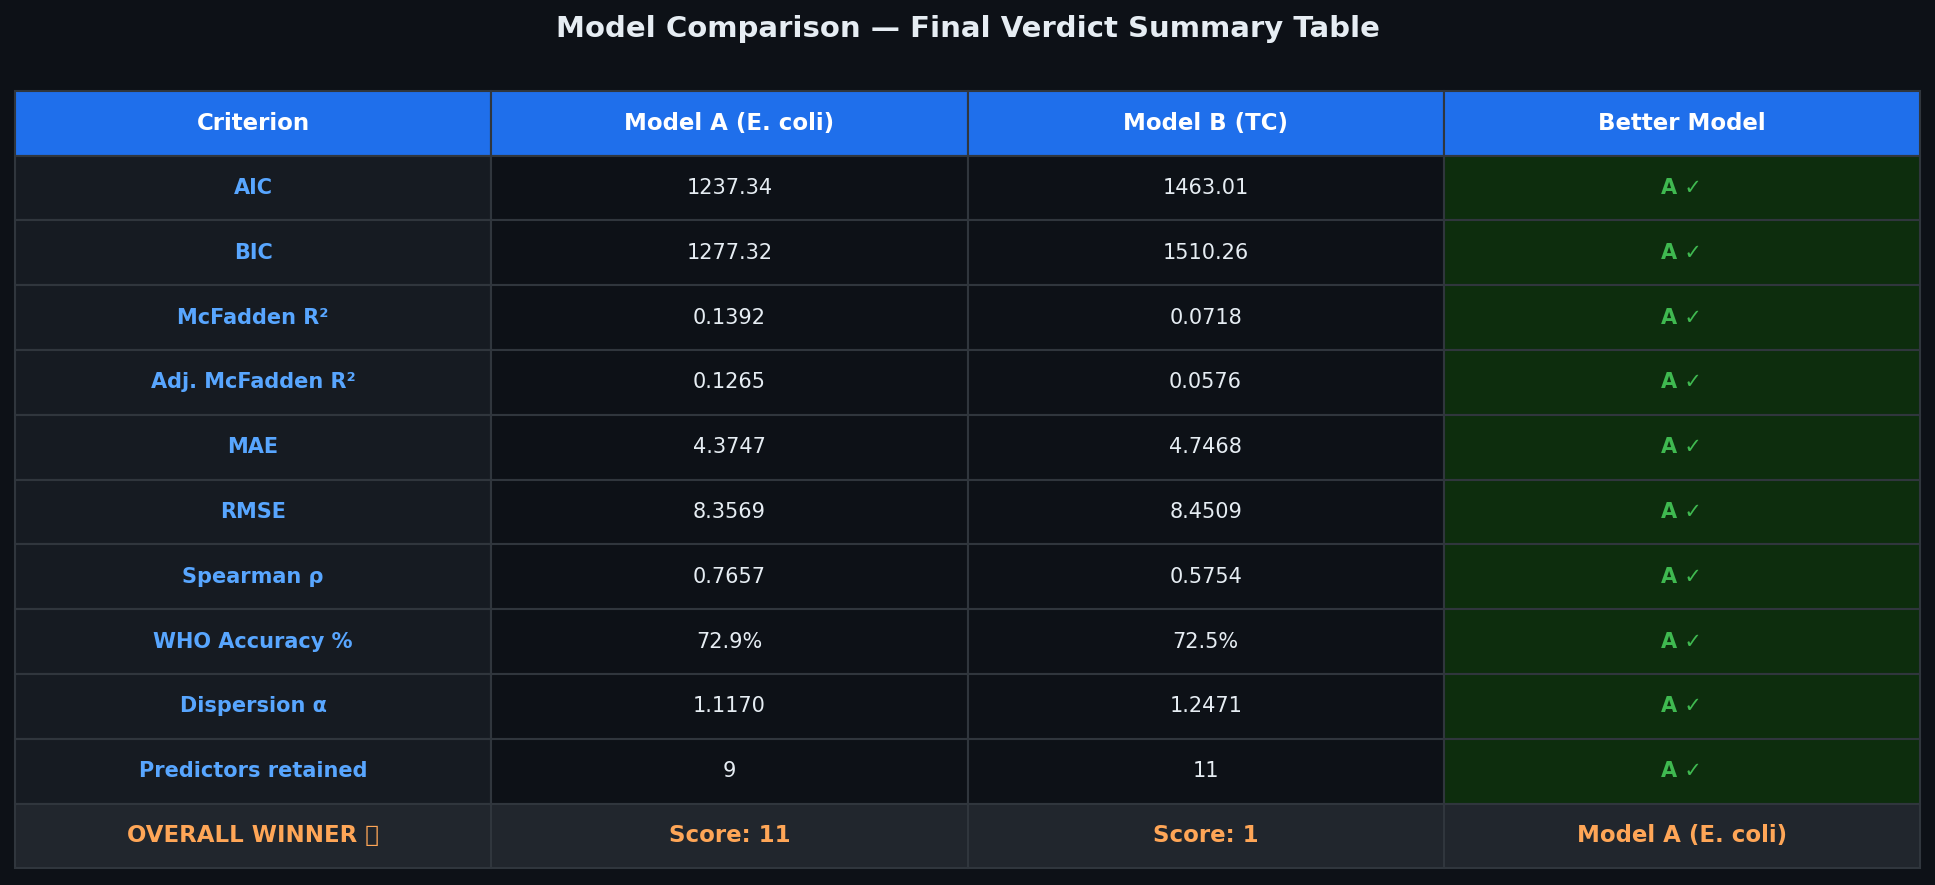

📊  Plot MC-6 rendered — Final verdict table.

══════════════════════════════════════════════════════════════════════
  ✅  MODEL COMPARISON COMPLETE
  🏆  OVERALL WINNER: Model A (E. coli)
      Model A wins on 11 metrics
      Model B wins on 1 metrics
══════════════════════════════════════════════════════════════════════


In [59]:


# ── PLOT MC-6 · Final verdict summary panel ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0d1117')
ax.axis('off')

summary_rows = [
    ['Criterion',           'Model A (E. coli)',
     'Model B (TC)',        'Better Model'],
    ['AIC',                 f"{metrics_ec['AIC']:.2f}",
     f"{metrics_tc['AIC']:.2f}",
     'A ✓' if metrics_ec['AIC'] < metrics_tc['AIC'] else 'B ✓'],
    ['BIC',                 f"{metrics_ec['BIC']:.2f}",
     f"{metrics_tc['BIC']:.2f}",
     'A ✓' if metrics_ec['BIC'] < metrics_tc['BIC'] else 'B ✓'],
    ['McFadden R²',         f"{metrics_ec['McFadden R²']:.4f}",
     f"{metrics_tc['McFadden R²']:.4f}",
     'A ✓' if metrics_ec['McFadden R²'] > metrics_tc['McFadden R²'] else 'B ✓'],
    ['Adj. McFadden R²',    f"{metrics_ec['Adj. McFadden R²']:.4f}",
     f"{metrics_tc['Adj. McFadden R²']:.4f}",
     'A ✓' if metrics_ec['Adj. McFadden R²'] > metrics_tc['Adj. McFadden R²'] else 'B ✓'],
    ['MAE',                 f"{metrics_ec['MAE']:.4f}",
     f"{metrics_tc['MAE']:.4f}",
     'A ✓' if metrics_ec['MAE'] < metrics_tc['MAE'] else 'B ✓'],
    ['RMSE',                f"{metrics_ec['RMSE']:.4f}",
     f"{metrics_tc['RMSE']:.4f}",
     'A ✓' if metrics_ec['RMSE'] < metrics_tc['RMSE'] else 'B ✓'],
    ['Spearman ρ',          f"{metrics_ec['Spearman ρ']:.4f}",
     f"{metrics_tc['Spearman ρ']:.4f}",
     'A ✓' if metrics_ec['Spearman ρ'] > metrics_tc['Spearman ρ'] else 'B ✓'],
    ['WHO Accuracy %',      f"{metrics_ec['WHO Accuracy %']:.1f}%",
     f"{metrics_tc['WHO Accuracy %']:.1f}%",
     'A ✓' if metrics_ec['WHO Accuracy %'] > metrics_tc['WHO Accuracy %'] else 'B ✓'],
    ['Dispersion α',        f"{metrics_ec['Dispersion α']:.4f}",
     f"{metrics_tc['Dispersion α']:.4f}",
     'A ✓' if metrics_ec['Dispersion α'] < metrics_tc['Dispersion α'] else 'B ✓'],
    ['Predictors retained', str(metrics_ec['Predictors']),
     str(metrics_tc['Predictors']),
     'A ✓' if metrics_ec['Predictors'] <= metrics_tc['Predictors'] else 'B ✓'],
    ['OVERALL WINNER 🏆',  f'Score: {score_A}',
     f'Score: {score_B}',
     winner_overall],
]

table = ax.table(cellText=summary_rows[1:], colLabels=summary_rows[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.3)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#0d1117')
    cell.set_edgecolor('#30363d')
    cell.set_text_props(color='#e6edf3')
    if row == 0:
        cell.set_facecolor('#1f6feb')
        cell.set_text_props(color='white', fontweight='bold', fontsize=11)
    if col == 0 and row > 0:
        cell.set_facecolor('#161b22')
        cell.set_text_props(color=ACCENT, fontweight='bold')
    if col == 3 and row > 0:
        val = cell.get_text().get_text()
        if 'A' in val:
            cell.set_facecolor('#0d2d0d')
            cell.set_text_props(color=GREEN, fontweight='bold')
        elif 'B' in val:
            cell.set_facecolor('#1e0d2e')
            cell.set_text_props(color=PURPLE, fontweight='bold')
    # Highlight overall winner row
    if row == len(summary_rows) - 1:
        for c in range(4):
            table[(row, c)].set_facecolor('#21262d')
            table[(row, c)].set_text_props(color=ORANGE, fontweight='bold',
                                            fontsize=11)

ax.set_title('Model Comparison — Final Verdict Summary Table',
             fontsize=14, pad=25, fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('mc_plot6_verdict_table.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("📊  Plot MC-6 rendered — Final verdict table.")

print(f"\n{'═'*70}")
print(f"  ✅  MODEL COMPARISON COMPLETE")
print(f"  🏆  OVERALL WINNER: {winner_overall}")
print(f"      Model A wins on {score_A} metrics")
print(f"      Model B wins on {score_B} metrics")
print(f"{'═'*70}")